In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
Obsid = ['20201214','20201213','20201212','20201211','20201210',
         '20201209','20201208','20201207','20201206','20201205',
         '20201204','20201203','20201202','20201201','20201130',
         '20201129','20201128','20201127','20201126','20201125',
         '20201124','20201122','20201121','20201120','20201119',
         '20201117','20201116','20201115','20201114']
#'20201118','20201214','20201112','20201110'
x = np.array([2.12, 2.48, 2.8, 3.15, 3.45,
              3.61, 4.12, 4.91, 5.1, 5.57,
              6.08, 6.69, 7.25, 7.43, 7.44, 
              8.11, 8.69, 9.14, 9.5, 9.67, 
              9.84, 10.55, 10.54, 11.04, 10.69, 
              10.24, 9.46, 8.1, 6.65])

y_b = np.array([0.240,0.160,0.168,0.196,0.207,
                0.208,0.215,0.216,0.239,0.322,
                0.245,0.219,0.206,0.220,0.305,
                0.196,0.273,0.295,0.433,0.284,
                0.235,0.241,0.362,0.324,0.300,
                0.305,0.448,0.225,0.164])

y_b_err = np.array([0.060,0.033,0.027,0.038,0.041,
                    0.050,0.030,0.047,0.048,0.073,
                    0.075,0.037,0.029,0.063,0.073,
                    0.031,0.055,0.076,0.116,0.044,
                    0.120,0.046,0.119,0.076,0.063,
                    0.123,0.125,0.065,0.084])

powerl-law model:
拟合得到的 K1 值: 7.3317 ± 1.1521
拟合得到的 Gamma1 值: 0.2836 ± 0.0852


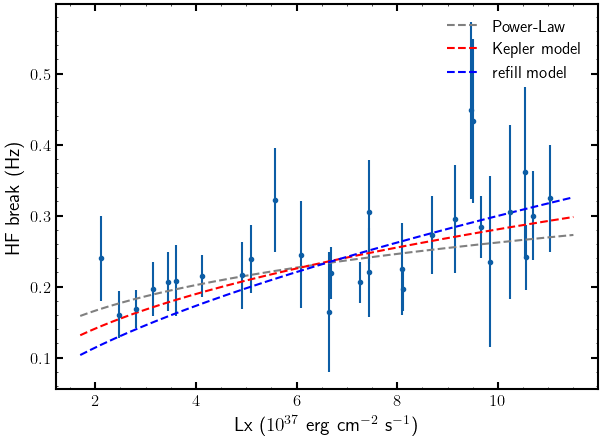

In [69]:
L37=x[:len(y_b)]
plt.errorbar(x[:len(y_b)],y_b,yerr=y_b_err,fmt='.')
def f_power_fit1(L37, K, Gamma):
    return 1 / (K * L37 ** (-Gamma))
def f_Keplar(L37, K):
    return 1 / (K * L37 ** (-3/7))
def f_refill(L37, K):
    return 1 / (K * L37 ** (-3/5))
# 拟合 f_power_fit1
K_init=10
Gamma_init=0.6

popt_power1, pcov_power1 = curve_fit(f_power_fit1, L37, y_b, sigma=y_b_err, absolute_sigma=True, p0=[K_init,Gamma_init])
K1_opt = popt_power1[0]
Gamma1_opt = popt_power1[1]
perr_power1 = np.sqrt(np.diag(pcov_power1))

popt_power2, pcov_power2 = curve_fit(f_Keplar, L37, y_b, sigma=y_b_err, absolute_sigma=True, p0=[K_init])
K2_opt = popt_power2[0]
perr_power2 = np.sqrt(np.diag(pcov_power2))

popt_power3, pcov_power3 = curve_fit(f_refill, L37, y_b, sigma=y_b_err, absolute_sigma=True, p0=[K_init])
K3_opt = popt_power3[0]
perr_power3 = np.sqrt(np.diag(pcov_power3))

L37_fit = np.arange(1.7, 11.5, 0.001)
f_power_fit1_values = f_power_fit1(L37_fit, K1_opt, Gamma1_opt)
plt.plot(L37_fit, f_power_fit1_values, label=f"Power-Law", color='gray',ls='--')

f_Keplar_values = f_Keplar(L37_fit, K2_opt)
plt.plot(L37_fit, f_Keplar_values, label=f"Kepler model", color='red',ls='--')

f_refill_values = f_refill(L37_fit, K3_opt)
plt.plot(L37_fit, f_refill_values, label=f"refill model", color='blue',ls='--')
plt.legend()
plt.ylabel('HF break (Hz)')
plt.xlabel(r'Lx ($10^{37}$ erg cm$^{-2}$ s$^{-1}$)')
print(f"powerl-law model:")
print(f"拟合得到的 K1 值: {K1_opt:.4f} ± {perr_power1[0]:.4f}")
print(f"拟合得到的 Gamma1 值: {Gamma1_opt:.4f} ± {perr_power1[1]:.4f}")
# print(f"拟合得到的 K2 值: {K2_opt:.4f} ± {perr_power2[0]:.4f}")
# print(f"拟合得到的 K3 值: {K3_opt:.4f} ± {perr_power3[0]:.4f}")


In [70]:
import numpy as np
import matplotlib.pyplot as plt
Obsid = ['20201214','20201213','20201212','20201211','20201210',
         '20201209','20201208','20201207','20201206','20201205',
         '20201204','20201203','20201202','20201201','20201130',
         '20201129','20201128','20201127','20201126','20201125',
         '20201124','20201122','20201121','20201120','20201119',
         '20201117','20201116','20201115','20201114']
#'20201118','20201214','20201112','20201110'
x = np.array([2.12, 2.48, 2.8, 3.15, 3.45,
              3.61, 4.12, 4.91, 5.1, 5.57,
              6.08, 6.69, 7.25, 7.43, 7.44, 
              8.11, 8.69, 9.14, 9.5, 9.67, 
              9.84, 10.55, 10.54, 11.04, 10.69, 
              10.24, 9.46, 8.1, 6.65])

y_L = np.array([7.05, 10.7, 11.8, 10.7, 18.8,
                14.8, 13.0, 14.9, 19.2, 18.8, 
                24.8, 14.7, 13.1, 22.6, 21.0, 
                14.5, 22.6, 17.3, 36.4, 16.9, 
                25.2, 20.0, 31.8, 24.6, 19.4, 
                24.7, 20.6, 14.0, 5.7])

y_L_err = np.array([4.9, 3.9, 3.5, 3, 5.2, 
                    4.8, 2.4, 4.6, 5.3, 4.2, 
                    7.4, 3.6, 4.3, 8.1, 4.4, 
                    5.6, 6.6, 7.1, 7.8, 4.3, 
                    18.7, 5.9, 6.7, 7.8, 5.3, 
                    8.1, 4.2, 4.0, 5.2])

powerl-law model:
拟合得到的 K1 值: 147.4499 ± 35.5845
拟合得到的 Gamma1 值: 0.4819 ± 0.1249


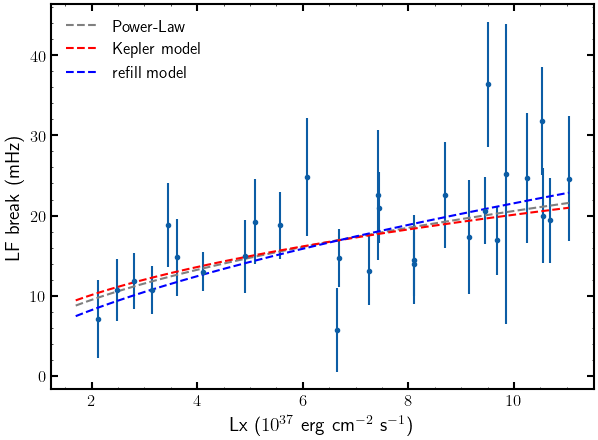

In [71]:
L37=x[:len(y_L)]
plt.errorbar(x[:len(y_L)],y_L,yerr=y_L_err,fmt='.')
def f_power_fit1(L37, K, Gamma):
    return 1000 / (K * L37 ** (-Gamma))
def f_Keplar(L37, K):
    return 1000 / (K * L37 ** (-3/7))
def f_refill(L37, K):
    return 1000 / (K * L37 ** (-3/5))
# 拟合 f_power_fit1
K_init=10
Gamma_init=0.6

popt_power1, pcov_power1 = curve_fit(f_power_fit1, L37, y_L, sigma=y_L_err, absolute_sigma=True, p0=[K_init,Gamma_init])
K1_opt = popt_power1[0]
Gamma1_opt = popt_power1[1]
perr_power1 = np.sqrt(np.diag(pcov_power1))

popt_power2, pcov_power2 = curve_fit(f_Keplar, L37, y_L, sigma=y_L_err, absolute_sigma=True, p0=[K_init])
K2_opt = popt_power2[0]
perr_power2 = np.sqrt(np.diag(pcov_power2))

popt_power3, pcov_power3 = curve_fit(f_refill, L37, y_L, sigma=y_L_err, absolute_sigma=True, p0=[K_init])
K3_opt = popt_power3[0]
perr_power3 = np.sqrt(np.diag(pcov_power3))

L37_fit = np.arange(1.7, np.max(x), 0.001)

f_power_fit1_values = f_power_fit1(L37_fit, K1_opt, Gamma1_opt)
plt.plot(L37_fit, f_power_fit1_values, label=f"Power-Law", color='gray',ls='--')

f_Keplar_values = f_Keplar(L37_fit, K2_opt)
plt.plot(L37_fit, f_Keplar_values, label=f"Kepler model", color='red',ls='--')

f_refill_values = f_refill(L37_fit, K3_opt)
plt.plot(L37_fit, f_refill_values, label=f"refill model", color='blue',ls='--')
plt.legend()
plt.ylabel('LF break (mHz)')
plt.xlabel(r'Lx ($10^{37}$ erg cm$^{-2}$ s$^{-1}$)')

print(f"powerl-law model:")
print(f"拟合得到的 K1 值: {K1_opt:.4f} ± {perr_power1[0]:.4f}")
print(f"拟合得到的 Gamma1 值: {Gamma1_opt:.4f} ± {perr_power1[1]:.4f}")
# print(f"拟合得到的 K2 值: {K2_opt:.4f} ± {perr_power2[0]:.4f}")
# print(f"拟合得到的 K3 值: {K3_opt:.4f} ± {perr_power3[0]:.4f}")



In [72]:
import numpy as np
import matplotlib.pyplot as plt
Obsid = ['20201215',
         '20201214','20201213','20201212','20201211','20201210',
         '20201209','20201208','20201207','20201206','20201205',
         '20201204','20201203','20201202','20201201','20201130',
         '20201129','20201128','20201127','20201126','20201125',
         '20201124','20201122','20201121','20201120','20201119',
         '20201118','20201117','20201116','20201115','20201114']
#'20201118','20201214','20201112','20201110'
x = np.array([1.87, 
              2.12, 2.48, 2.8, 3.15, 3.45,
              3.61, 4.12, 4.91, 5.1, 5.57,
              6.08, 6.69, 7.25, 7.43, 7.44, 
              8.11, 8.69, 9.14, 9.5, 9.67, 
              9.84, 10.55, 10.54, 11.04, 10.69, 
              10.94,10.24, 9.46, 8.1, 6.65])

y = np.array([30.8,
              34, 35.2, 39, 40.6, 45.5,
              45.8, 50.1, 54.7, 56.5, 59.1, 
              62.4, 64.8, 68.5, 68, 71.9, 
              76.5, 80.9, 82.5, 85.7, 89.9, 
              89.6, 87.7, 89.8, 94.0, 88.1, 
              93, 89.5, 85.3, 78.6, 59.2])

y_err = np.array([2.1,
                  6, 2, 1.5, 2, 1,
                  2, 1, 2, 1, 1.5,
                  2, 2, 2, 4, 2, 
                  2, 2, 4, 3, 3, 
                  5, 4, 3, 3, 4, 
                  3,3, 3, 4, 5])

In [73]:
x = np.array([
    0.48, 0.99, 1.42, 1.83, 2.65, 3.34,
    3.93, 4.06, 4.23, 3.76, 3.69, 3.33,
    3.00, 2.72, 2.37, 2.17, 1.72, 1.44,
    1.26, 1.01, 0.82, 0.67
])

x_err = np.array([
    0.02, 0.03, 0.05, 0.10, 0.08, 0.11,
    0.11, 0.17, 0.15, 0.13, 0.10, 0.11,
    0.09, 0.09, 0.08, 0.07, 0.05, 0.05,
    0.04, 0.03, 0.02, 0.02
])

y = np.array([
    29.33, 35.35, 40.82, 47.04, 56.79, 64.26,
    69.13, 70.70, 71.53, 66.44, 66.60, 64.19,
    57.68, 55.73, 50.46, 47.26, 41.65, 41.39,
    36.85, 34.94, 32.43, 27.65
])

y_err = np.array([
    0.66, 0.71, 0.73, 0.81, 0.70, 0.79,
    0.92, 0.94, 0.86, 0.91, 0.79, 0.85,
    1.20, 0.69, 0.77, 0.58, 0.56, 0.82,
    0.75, 0.62, 0.57, 1.15
])

x_baste = x
x_err_baste = x_err
y_baste = y
y_err_baste = y_err

In [74]:
import numpy as np
import matplotlib.pyplot as plt
Obsid = ['20201215',
         '20201214','20201213','20201212','20201211','20201210',
         '20201209','20201208','20201207','20201206','20201205',
         '20201204','20201203','20201202','20201201','20201130',
         '20201129','20201128','20201127','20201126','20201125',
         '20201124','20201122','20201121','20201120','20201119','20201118'
         '20201117','20201116','20201115','20201114','20201110']
#'20201118','20201214','20201112','20201110'
x = np.array([1.87, 
              2.12, 2.48, 2.8, 3.15, 3.45,
              3.61, 4.12, 4.91, 5.1, 5.57,
              6.08, 6.69, 7.25, 7.43, 7.44, 
              8.11, 8.69, 9.14, 9.5, 9.67, 
              9.84, 10.55, 10.54, 11.04, 10.69, 10.70,
              10.24, 9.46, 8.1, 6.65, 2.15])

x_err = np.array([0.01, 
              0.01, 0.01, 0.01, 0.01, 0.01,
              0.01, 0.01, 0.01, 0.01, 0.01,
              0.01, 0.01, 0.01, 0.01, 0.01, 
              0.01, 0.01, 0.01, 0.01, 0.01, 
              0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
              0.01, 0.01, 0.01, 0.01, 0.01])

y = np.array([29.5,
              35.5, 37.8, 38.7, 41.6, 44.4,
              46.5, 49.3, 54.7, 56.5, 57.1, 
              61.6, 64.2, 68.7, 67.0, 71.4, 
              75.9, 81.5, 84.2, 82.5, 89.2, 
              86.5, 86.1, 87.8, 92.7, 86.9, 93.0,
              89.2, 85.3, 78.0, 58.9, 31.1])

y_err = np.array([2.1,
                  2, 2, 1.5, 1, 1,
                  1, 1, 1, 1, 2.5,
                  2, 1, 2, 2, 2, 
                  2, 2, 3, 3, 3, 
                  5, 4, 3, 2, 3, 3,
                  3, 3, 3, 5, 4])

x_hxmt = x
x_err_hxmt = x_err
y_hxmt = y
y_err_hxmt = y_err

In [75]:
# 给定的常量
m = 1.4  # 归一化质量
R6 = 1.0  # 归一化半径 (R6 = R / 10^6 cm)
B12 = 5.4  # 归一化磁场强度 (B12 = B / 10^12 G)
d_kpc = 2  # 距离 (kpc)
Lambda = 0.1  # 假设 Lambda = 0.5
d_cm = d_kpc * 3.086e21  # 转换为 cm

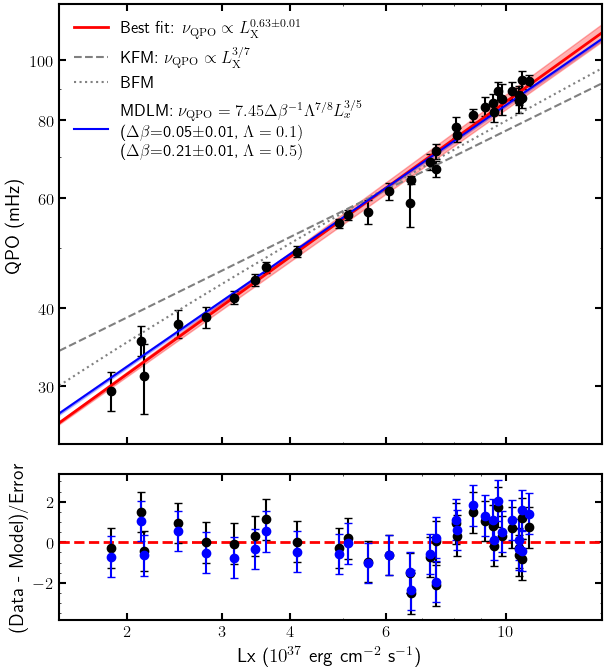

拟合得到的 K 值: 49.1740 ± 1.0939
拟合得到的 Gamma 值: 0.6250 ± 0.0119
拟合得到的 K1 值: 34.8067 ± 0.1773
拟合得到的 Beta 值: 0.0518 ± 0.0003
r2_power 拟合的 R² 值: 0.9841
r2_r 拟合的 R² 值: 0.9810


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
# 计算 L37 (转换为 10^37 erg/s)
L37 = x_hxmt

# 定义 t_th 拟合函数 (alpha 作为拟合参数)
def f_power_fit(L37, K, Gamma):
    return 1000 / (K * L37 ** (-Gamma))

def f_power_fit1(L37, K):
    return 1000 / (K * L37 ** (-3/7))

def f_power_fit2(L37, K):
    return 1000 / (K * L37 ** (-3/7))-9.67

def f_power_fit3(L37, K):
    return 1000 / (K * L37 ** (-0.55))

# 定义 t_r 拟合函数 (Beta 作为拟合参数)
def f_r_fit(L37, Beta):
    return 1000 / (12 * Beta * Lambda**(-7/8) * m**(-13/20) * R6**(29/10) * B12**(3/2) * L37**(-3/5))

# def f_r_fit(L37, Beta):
#     return 7.45* Beta**(-1) * Lambda**(7/8) * L37**(3/5)


# 初始参数
Beta_init = 0.01
Gamma_init = 0.6
K_init = 30


# 拟合 f_power_fit
popt_power, pcov_power = curve_fit(f_power_fit, L37, y_hxmt, sigma=y_err_hxmt, absolute_sigma=True, p0=[K_init, Gamma_init])
K_opt, Gamma_opt = popt_power
perr_power = np.sqrt(np.diag(pcov_power))  # 参数误差

# 拟合 f_power_fit1
popt_power1, pcov_power1 = curve_fit(f_power_fit1, L37, y_hxmt, sigma=y_err_hxmt, absolute_sigma=True, p0=[K_init])
K1_opt = popt_power1[0]
perr_power1 = np.sqrt(np.diag(pcov_power1))

# 拟合 f_power_fit2
popt_power2, pcov_power2 = curve_fit(f_power_fit2, L37, y_hxmt, sigma=y_err_hxmt, absolute_sigma=True, p0=[K_init])
K2_opt = popt_power2[0]
perr_power2 = np.sqrt(np.diag(pcov_power2))

# 拟合 f_power_fit3
popt_power3, pcov_power3 = curve_fit(f_power_fit3, L37, y_hxmt, sigma=y_err_hxmt, absolute_sigma=True, p0=[K_init])
K3_opt = popt_power3[0]
perr_power3 = np.sqrt(np.diag(pcov_power3))

# 拟合 f_r_fit
popt_r, pcov_r = curve_fit(f_r_fit, L37, y_hxmt, sigma=y_err_hxmt, absolute_sigma=True, p0=[Beta_init])
Beta_opt = popt_r[0]
perr_r = np.sqrt(np.diag(pcov_r))

# 计算拟合曲线
#L37_fit = np.arange(np.min(x_hxmt)-0.2, np.max(x_hxmt)+0.5, 0.001)
L37_fit = np.linspace(1.5, 15, 1000)


f_power_fit_values = f_power_fit(L37_fit, K_opt, Gamma_opt)
f_power_fit1_values = f_power_fit1(L37_fit, K1_opt)
f_power_fit2_values = f_power_fit2(L37_fit, K2_opt)
f_power_fit3_values = f_power_fit3(L37_fit, K3_opt)
f_r_fit_values = f_r_fit(L37_fit, Beta_opt)

# 计算残差
residuals_power = (y_hxmt - f_power_fit(L37, K_opt, Gamma_opt)) / y_err_hxmt
residuals_power1 = (y_hxmt - f_power_fit1(L37, K1_opt)) / y_err_hxmt
residuals_power2 = (y_hxmt - f_power_fit2(L37, K2_opt)) / y_err_hxmt
residuals_power3 = (y_hxmt - f_power_fit3(L37, K3_opt)) / y_err_hxmt
residuals_r = (y_hxmt - f_r_fit(L37, Beta_opt)) / y_err_hxmt

# 计算 R² 值
def r_squared(y_obs, y_fit):
    ss_res = np.sum((y_obs - y_fit) ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_power = r_squared(y_hxmt, f_power_fit(L37, K_opt, Gamma_opt))
r2_power1 = r_squared(y_hxmt, f_power_fit1(L37, K1_opt))
r2_power2 = r_squared(y_hxmt, f_power_fit2(L37, K2_opt))
r2_power3 = r_squared(y_hxmt, f_power_fit3(L37, K3_opt))
r2_r = r_squared(y_hxmt, f_r_fit(L37, Beta_opt))

# 创建子图
fig, axs = plt.subplots(2, 1, figsize=(7, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
#axs[0].set_xscale('log')
#axs[0].set_yscale('log')
axs[0].set_ylabel(r'QPO (mHz)')
#axs[0].set_title(r'Luminosity vs. QPO')

# axs[1].set_xscale('log')
axs[1].set_xlabel(r'Lx ($10^{37}$ erg cm$^{-2}$ s$^{-1}$)')
axs[1].set_ylabel("(Data - Model)/Error")

# 第一张子图: 拟合曲线

axs[0].errorbar(x_hxmt, y_hxmt,xerr=x_err_hxmt, yerr=y_err_hxmt, fmt='o', color='black', capsize=3)
axs[0].plot(L37_fit, f_power_fit_values, label=r"Best fit: $\nu_{\rm QPO}\propto L_{\rm X}^{%0.2f\pm%0.2f}$"%(Gamma_opt,perr_power[1]), color='red',lw=2)
axs[0].plot(L37_fit, f_power_fit1_values, label=r"KFM: $\nu_{\rm QPO}\propto L_{\rm X}^{3/7}$", color='gray',ls='--')
axs[0].plot(L37_fit, f_power_fit2_values, label=r"BFM", color='gray',ls=':')
#axs[0].plot(L37_fit, f_power_fit3_values, label=r"MDPM: $\nu_{\rm QPO}\propto L_{x}^{0.55}}$", color='green')
axs[0].plot(L37_fit, f_r_fit_values, 
            label=r"MDLM: $\nu_{\rm QPO} =  7.45\Delta\beta^{-1}\Lambda^{7/8} L_{x}^{3/5}$"+"\n" +r"($\Delta \beta$=%.2f±0.01, $\Lambda=0.1)$"%Beta_opt+"\n" + r"($\Delta \beta$=0.21±0.01, $\Lambda=0.5)$", 
            color='blue')
# ===== Beta 不确定性阴影（MDLM）=====

Beta_upper = Beta_opt + perr_r[0]
Beta_lower = Beta_opt - perr_r[0]

# 注意：beta 在分母里，upper/lower 会反过来
fit_r_upper = f_r_fit(L37_fit, Beta_lower)  # beta 小 → 频率大
fit_r_lower = f_r_fit(L37_fit, Beta_upper)  # beta 大 → 频率小

axs[0].fill_between(
    L37_fit,
    fit_r_lower,
    fit_r_upper,
    color='blue',
    alpha=0.25
)

# 计算误差上下界对应的拟合曲线
Gamma_upper = Gamma_opt + perr_power[1]
Gamma_lower = Gamma_opt - perr_power[1]

fit_upper = f_power_fit(L37_fit, K_opt, Gamma_upper)
fit_lower = f_power_fit(L37_fit, K_opt, Gamma_lower)

# 添加拟合曲线误差阴影区域
axs[0].fill_between(L37_fit, fit_lower, fit_upper, color='red', alpha=0.3)


axs[0].legend(loc='upper left')
axs[0].set_xscale('log')
axs[0].set_yscale('log')



#axs[0].set_xlim(1.7,11.5)
# 第二张子图: 残差
axs[1].axhline(0, color='red', linestyle='--', linewidth=2)
axs[1].errorbar(x_hxmt, residuals_power, yerr=y_err_hxmt/y_err_hxmt, fmt='o', color='black',capsize=3)
# axs[1].errorbar(x, residuals_power1, yerr=y_err/y_err, fmt='o', color='gray',capsize=3)
# axs[1].errorbar(x, residuals_power2, yerr=y_err/y_err, fmt='o', color='gray',capsize=3)
# axs[1].errorbar(x, residuals_power3, yerr=y_err/y_err, fmt='o', color='green',capsize=3)
axs[1].errorbar(x_hxmt, residuals_r, yerr=y_err_hxmt/y_err_hxmt, fmt='o', color='blue',capsize=3)
#axs[1].errorbar(x[24:], residuals_r[24:], yerr=y_err[24:]/y_err[24:], fmt='s', color='green', capsize=3)
#axs[1].set_ylim(-3.5,3.5)
axs[1].set_xscale('log')
#plt.tight_layout()




from matplotlib.ticker import LogLocator, ScalarFormatter

axs[0].xaxis.set_major_locator(LogLocator(base=10, subs=[2, 3, 4, 6, 10]))
axs[0].xaxis.set_major_formatter(ScalarFormatter())

axs[0].yaxis.set_major_locator(LogLocator(base=10, subs=[30, 40, 60, 80, 100]))
axs[0].yaxis.set_major_formatter(ScalarFormatter())

axs[0].set_xlim(1.5,15)
axs[1].set_xlim(1.5,15)
#plt.tight_layout
plt.subplots_adjust(wspace=0, hspace=0.1)
plt.savefig('QPO_Lum_modelfit_new.pdf')
plt.show()

# 输出拟合结果
print(f"拟合得到的 K 值: {K_opt:.4f} ± {perr_power[0]:.4f}")
print(f"拟合得到的 Gamma 值: {Gamma_opt:.4f} ± {perr_power[1]:.4f}")
print(f"拟合得到的 K1 值: {K1_opt:.4f} ± {perr_power1[0]:.4f}")
print(f"拟合得到的 Beta 值: {Beta_opt:.4f} ± {perr_r[0]:.4f}")
print(f"r2_power 拟合的 R² 值: {r2_power:.4f}")
print(f"r2_r 拟合的 R² 值: {r2_r:.4f}")




In [77]:
# =========================
# 1) 两组数据：请你把数组填进这里
# =========================
# --- HXMT (2020) ---
x_hxmt     = x_hxmt    # Lx in 1e37 erg/s
xerr_hxmt  = x_err_hxmt
y_hxmt     = y_hxmt     # QPO (mHz)
yerr_hxmt  = y_err_hxmt

# --- Historical (Finger/BATSE; after d=2 kpc conversion) ---
x_hist     = x_baste
xerr_hist  = x_err_baste
y_hist     = y_baste
yerr_hist  = y_err_baste

Plot range: 0.432 11.591999999999999


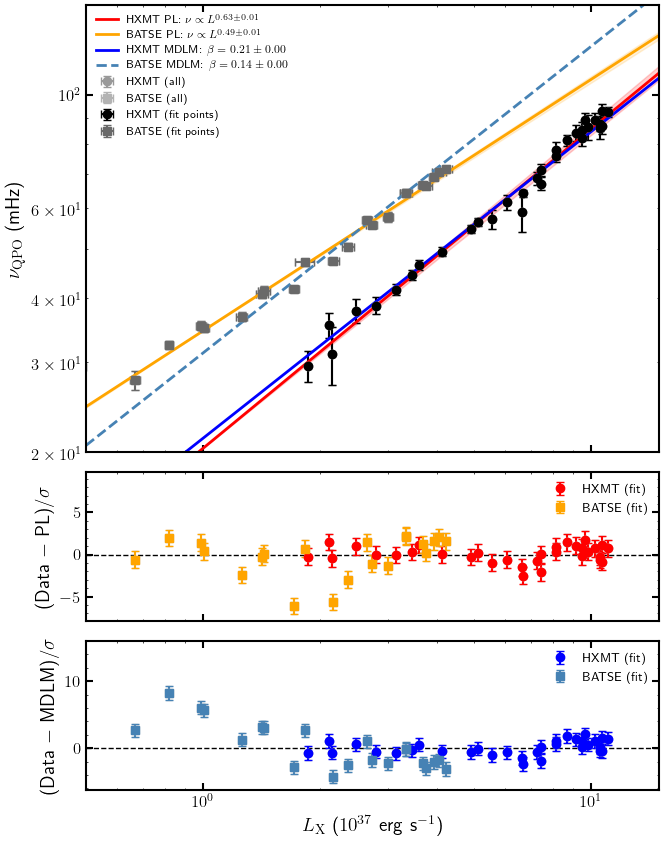

========== HXMT (fit range) ==========
Range: [None, None]  Nfit=32/32
PL:   K = 49.1740 ± 1.0939,  Gamma = 0.6250 ± 0.0119
MDLM: Beta = 0.21179 ± 0.00108
R2(PL)=0.9841,  chi2_red(PL)=1.050 (dof=30)
R2(MDLM)=0.9810, chi2_red(MDLM)=1.156 (dof=31)

========== BATSE (fit range) ==========
Range: [None, None]  Nfit=22/22
PL:   K = 28.9710 ± 0.1881,  Gamma = 0.4921 ± 0.0064
MDLM: Beta = 0.14424 ± 0.00046
R2(PL)=0.9817,  chi2_red(PL)=9.023 (dof=20)
R2(MDLM)=0.9526, chi2_red(MDLM)=20.953 (dof=21)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# 0) 你需要提前准备两组数据（示例变量名）
#    x_hxmt, xerr_hxmt, y_hxmt, yerr_hxmt
#    x_hist, xerr_hist, y_hist, yerr_hist
# ============================================================

# ============================================================
# 1) 模型定义
# ============================================================
def f_power_fit(L37, K, Gamma):
    # 1000/(K*L^{-Gamma}) = (1000/K)*L^{Gamma}
    return 1000.0 / (K * L37**(-Gamma))

def f_kfm(L37, K):
    # KFM slope fixed at 3/7
    return 1000.0 / (K * L37**(-3/7))

# ---- MDLM (常数因子写法) ----
m = 1.4
R6 = 1.0
B12 = 5.4
Lambda = 0.5

A_factor = 12.0 * (Lambda**(-7/8)) * (m**(-13/20)) * (R6**(29/10)) * (B12**(3/2))

def f_mdlm(L37, Beta):
    return 1000.0 / (A_factor * Beta * L37**(-3/5))


# ============================================================
# 2) 拟合函数（带光度范围筛选）
# ============================================================
def fit_one_dataset(
    x, y, yerr,
    K_init=30.0, Gamma_init=0.6, Beta_init=0.01,
    Lmin=None, Lmax=None,
    return_mask=True
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    # --- selection mask ---
    mask = np.ones_like(x, dtype=bool)
    if Lmin is not None:
        mask &= (x >= Lmin)
    if Lmax is not None:
        mask &= (x <= Lmax)

    if mask.sum() < 3:
        raise ValueError(
            f"Too few points ({mask.sum()}) in selected range "
            f"[{Lmin}, {Lmax}]. Please widen the range."
        )
    if np.any(yerr[mask] <= 0):
        raise ValueError("yerr must be positive for all selected points.")

    x_fit = x[mask]
    y_fit = y[mask]
    yerr_fit = yerr[mask]

    # --- Power-law (K, Gamma) ---
    popt_pl, pcov_pl = curve_fit(
        f_power_fit, x_fit, y_fit,
        sigma=yerr_fit, absolute_sigma=True,
        p0=[K_init, Gamma_init],
        maxfev=20000
    )
    perr_pl = np.sqrt(np.diag(pcov_pl))

    # --- KFM (K only) ---
    popt_kfm, pcov_kfm = curve_fit(
        f_kfm, x_fit, y_fit,
        sigma=yerr_fit, absolute_sigma=True,
        p0=[K_init],
        maxfev=20000
    )
    perr_kfm = np.sqrt(np.diag(pcov_kfm))

    # --- MDLM (Beta only; Beta>0) ---
    popt_mdlm, pcov_mdlm = curve_fit(
        f_mdlm, x_fit, y_fit,
        sigma=yerr_fit, absolute_sigma=True,
        p0=[Beta_init],
        bounds=(1e-6, np.inf),
        maxfev=20000
    )
    perr_mdlm = np.sqrt(np.diag(pcov_mdlm))

    if return_mask:
        return (popt_pl, perr_pl), (popt_kfm, perr_kfm), (popt_mdlm, perr_mdlm), mask
    else:
        return (popt_pl, perr_pl), (popt_kfm, perr_kfm), (popt_mdlm, perr_mdlm)


# ============================================================
# 3) R^2 / chi2
# ============================================================
def chi2_red(y, yfit, yerr, npar):
    chi2 = np.sum(((y - yfit) / yerr)**2)
    dof = len(y) - npar
    return chi2 / dof, chi2, dof

def r_squared(y_obs, y_fit):
    ss_res = np.sum((y_obs - y_fit) ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    return 1 - (ss_res / ss_tot)


# ============================================================
# 4) 选择拟合范围（你只需要改这里）
#    None 表示不限制
# ============================================================
Lmin_hxmt, Lmax_hxmt = None, None   # 例如: 3.0, 12.0
Lmin_hist, Lmax_hist = None, None   # 例如: 0.8, 4.5


# ============================================================
# 5) 运行拟合（两组独立 + 记录mask）
# ============================================================
(pl_hxmt, kfm_hxmt, mdlm_hxmt, mask_hxmt) = fit_one_dataset(
    x_hxmt, y_hxmt, yerr_hxmt,
    Lmin=Lmin_hxmt, Lmax=Lmax_hxmt
)
(K_hxmt, G_hxmt) = pl_hxmt[0]
(eK_hxmt, eG_hxmt) = pl_hxmt[1]
(Kk_hxmt,) = kfm_hxmt[0]
(eKk_hxmt,) = kfm_hxmt[1]
(B_hxmt,) = mdlm_hxmt[0]
(eB_hxmt,) = mdlm_hxmt[1]

(pl_hist, kfm_hist, mdlm_hist, mask_hist) = fit_one_dataset(
    x_hist, y_hist, yerr_hist,
    Lmin=Lmin_hist, Lmax=Lmax_hist
)
(K_hist, G_hist) = pl_hist[0]
(eK_hist, eG_hist) = pl_hist[1]
(Kk_hist,) = kfm_hist[0]
(eKk_hist,) = kfm_hist[1]
(B_hist,) = mdlm_hist[0]
(eB_hist,) = mdlm_hist[1]


# ============================================================
# 6) 准备拟合曲线（x轴范围仍用“全部数据”）
# ============================================================
xmin = min(np.min(x_hxmt), np.min(x_hist)) * 0.9
xmax = max(np.max(x_hxmt), np.max(x_hist)) * 1.05
print("Plot range:", xmin, xmax)
Lfit = np.linspace(0.5, 15, 2000)

pl_hxmt_fit   = f_power_fit(Lfit, K_hxmt, G_hxmt)
pl_hist_fit   = f_power_fit(Lfit, K_hist, G_hist)
mdlm_hxmt_fit = f_mdlm(Lfit, B_hxmt)
mdlm_hist_fit = f_mdlm(Lfit, B_hist)

def pl_gamma_band(L, K, G, eG):
    y_up = f_power_fit(L, K, G + eG)
    y_lo = f_power_fit(L, K, G - eG)
    return y_lo, y_up


# ============================================================
# 7) 残差：用全部点画，但“参与拟合的点”高亮（推荐）
# ============================================================
res_hxmt_pl_all   = (y_hxmt - f_power_fit(x_hxmt, K_hxmt, G_hxmt)) / yerr_hxmt
res_hist_pl_all   = (y_hist - f_power_fit(x_hist, K_hist, G_hist)) / yerr_hist
res_hxmt_mdlm_all = (y_hxmt - f_mdlm(x_hxmt, B_hxmt)) / yerr_hxmt
res_hist_mdlm_all = (y_hist - f_mdlm(x_hist, B_hist)) / yerr_hist


# ============================================================
# 8) 作图：三联图
# ============================================================
fig, axs = plt.subplots(
    3, 1, figsize=(7.4, 10.2),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1, 1]}
)

# ---------- Top panel ----------
axs[0].set_ylabel(r'$\nu_{\rm QPO}$ (mHz)')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(2e1, 1.5e2)
# axs[0].set_xlim(0.5,15)
# 全部数据（浅色）
axs[0].errorbar(x_hxmt, y_hxmt, xerr=xerr_hxmt, yerr=yerr_hxmt,
               fmt='o', color='0.6', capsize=3, label='HXMT (all)')
axs[0].errorbar(x_hist, y_hist, xerr=xerr_hist, yerr=yerr_hist,
               fmt='s', color='0.7', capsize=3, label='BATSE (all)')

# 参与拟合的数据（深色高亮）
axs[0].errorbar(x_hxmt[mask_hxmt], y_hxmt[mask_hxmt],
               xerr=xerr_hxmt[mask_hxmt], yerr=yerr_hxmt[mask_hxmt],
               fmt='o', color='black', capsize=3, label='HXMT (fit points)')
axs[0].errorbar(x_hist[mask_hist], y_hist[mask_hist],
               xerr=xerr_hist[mask_hist], yerr=yerr_hist[mask_hist],
               fmt='s', color='dimgray', capsize=3, label='BATSE (fit points)')

# 拟合曲线
axs[0].plot(Lfit, pl_hxmt_fit, lw=2, color='red',
            label=rf'HXMT PL: $\nu\propto L^{{{G_hxmt:.2f}\pm{eG_hxmt:.2f}}}$')
axs[0].plot(Lfit, pl_hist_fit, lw=2, color='orange',
            label=rf'BATSE PL: $\nu\propto L^{{{G_hist:.2f}\pm{eG_hist:.2f}}}$')
axs[0].plot(Lfit, mdlm_hxmt_fit, lw=2, color='blue',
            label=rf'HXMT MDLM: $\beta={B_hxmt:.2f}\pm{eB_hxmt:.2f}$')
axs[0].plot(Lfit, mdlm_hist_fit, lw=2, color='steelblue', ls='--',
            label=rf'BATSE MDLM: $\beta={B_hist:.2f}\pm{eB_hist:.2f}$')

# PL Gamma 阴影
lo, up = pl_gamma_band(Lfit, K_hxmt, G_hxmt, eG_hxmt)
axs[0].fill_between(Lfit, lo, up, color='red', alpha=0.18)
lo, up = pl_gamma_band(Lfit, K_hist, G_hist, eG_hist)
axs[0].fill_between(Lfit, lo, up, color='orange', alpha=0.15)

axs[0].legend(loc='upper left', fontsize=8)

# ---------- Middle panel: PL residual ----------
axs[1].set_ylabel(r'(Data $-$ PL)/$\sigma$')
axs[1].set_xlim(0.5,15)
axs[1].axhline(0, color='k', ls='--', lw=1)

axs[1].errorbar(x_hxmt, res_hxmt_pl_all, yerr=np.ones_like(res_hxmt_pl_all),
                fmt='o', color='0.7', capsize=2)
axs[1].errorbar(x_hist, res_hist_pl_all, yerr=np.ones_like(res_hist_pl_all),
                fmt='s', color='0.75', capsize=2)

axs[1].errorbar(x_hxmt[mask_hxmt], res_hxmt_pl_all[mask_hxmt],
                yerr=np.ones_like(res_hxmt_pl_all[mask_hxmt]),
                fmt='o', color='red', capsize=3, label='HXMT (fit)')
axs[1].errorbar(x_hist[mask_hist], res_hist_pl_all[mask_hist],
                yerr=np.ones_like(res_hist_pl_all[mask_hist]),
                fmt='s', color='orange', capsize=3, label='BATSE (fit)')

# axs[1].set_ylim(-4, 4)
axs[1].legend(loc='upper right', fontsize=9)

# ---------- Bottom panel: MDLM residual ----------
axs[2].set_xlabel(r'$L_{\rm X}$ ($10^{37}$ erg s$^{-1}$)')
axs[2].set_ylabel(r'(Data $-$ MDLM)/$\sigma$')
axs[2].axhline(0, color='k', ls='--', lw=1)
axs[2].set_xlim(0.5,15)

axs[2].errorbar(x_hxmt, res_hxmt_mdlm_all, yerr=np.ones_like(res_hxmt_mdlm_all),
                fmt='o', color='0.7', capsize=2)
axs[2].errorbar(x_hist, res_hist_mdlm_all, yerr=np.ones_like(res_hist_mdlm_all),
                fmt='s', color='0.75', capsize=2)

axs[2].errorbar(x_hxmt[mask_hxmt], res_hxmt_mdlm_all[mask_hxmt],
                yerr=np.ones_like(res_hxmt_mdlm_all[mask_hxmt]),
                fmt='o', color='blue', capsize=3, label='HXMT (fit)')
axs[2].errorbar(x_hist[mask_hist], res_hist_mdlm_all[mask_hist],
                yerr=np.ones_like(res_hist_mdlm_all[mask_hist]),
                fmt='s', color='steelblue', capsize=3, label='BATSE (fit)')

# axs[2].set_ylim(-4, 4)
axs[2].legend(loc='upper right', fontsize=9)

plt.subplots_adjust(hspace=0.08)
plt.savefig('QPO_Lum_HXMT_BASTE_fit1.pdf')
plt.show()


# ============================================================
# 9) 打印拟合结果 + chi2_red / R2
#    注意：统计量也建议用“参与拟合点”计算（更一致）
# ============================================================
print("========== HXMT (fit range) ==========")
print(f"Range: [{Lmin_hxmt}, {Lmax_hxmt}]  Nfit={mask_hxmt.sum()}/{len(x_hxmt)}")
print(f"PL:   K = {K_hxmt:.4f} ± {eK_hxmt:.4f},  Gamma = {G_hxmt:.4f} ± {eG_hxmt:.4f}")
print(f"MDLM: Beta = {B_hxmt:.5f} ± {eB_hxmt:.5f}")

r2_hxmt_pl = r_squared(y_hxmt[mask_hxmt], f_power_fit(x_hxmt[mask_hxmt], K_hxmt, G_hxmt))
r2_hxmt_m  = r_squared(y_hxmt[mask_hxmt], f_mdlm(x_hxmt[mask_hxmt], B_hxmt))
chi2r_hxmt_pl, chi2_hxmt_pl, dof_hxmt_pl = chi2_red(
    y_hxmt[mask_hxmt], f_power_fit(x_hxmt[mask_hxmt], K_hxmt, G_hxmt), yerr_hxmt[mask_hxmt], npar=2
)
chi2r_hxmt_m, chi2_hxmt_m, dof_hxmt_m = chi2_red(
    y_hxmt[mask_hxmt], f_mdlm(x_hxmt[mask_hxmt], B_hxmt), yerr_hxmt[mask_hxmt], npar=1
)
print(f"R2(PL)={r2_hxmt_pl:.4f},  chi2_red(PL)={chi2r_hxmt_pl:.3f} (dof={dof_hxmt_pl})")
print(f"R2(MDLM)={r2_hxmt_m:.4f}, chi2_red(MDLM)={chi2r_hxmt_m:.3f} (dof={dof_hxmt_m})")

print("\n========== BATSE (fit range) ==========")
print(f"Range: [{Lmin_hist}, {Lmax_hist}]  Nfit={mask_hist.sum()}/{len(x_hist)}")
print(f"PL:   K = {K_hist:.4f} ± {eK_hist:.4f},  Gamma = {G_hist:.4f} ± {eG_hist:.4f}")
print(f"MDLM: Beta = {B_hist:.5f} ± {eB_hist:.5f}")

r2_hist_pl = r_squared(y_hist[mask_hist], f_power_fit(x_hist[mask_hist], K_hist, G_hist))
r2_hist_m  = r_squared(y_hist[mask_hist], f_mdlm(x_hist[mask_hist], B_hist))
chi2r_hist_pl, chi2_hist_pl, dof_hist_pl = chi2_red(
    y_hist[mask_hist], f_power_fit(x_hist[mask_hist], K_hist, G_hist), yerr_hist[mask_hist], npar=2
)
chi2r_hist_m, chi2_hist_m, dof_hist_m = chi2_red(
    y_hist[mask_hist], f_mdlm(x_hist[mask_hist], B_hist), yerr_hist[mask_hist], npar=1
)
print(f"R2(PL)={r2_hist_pl:.4f},  chi2_red(PL)={chi2r_hist_pl:.3f} (dof={dof_hist_pl})")
print(f"R2(MDLM)={r2_hist_m:.4f}, chi2_red(MDLM)={chi2r_hist_m:.3f} (dof={dof_hist_m})")

Plot range: 0.432 11.591999999999999


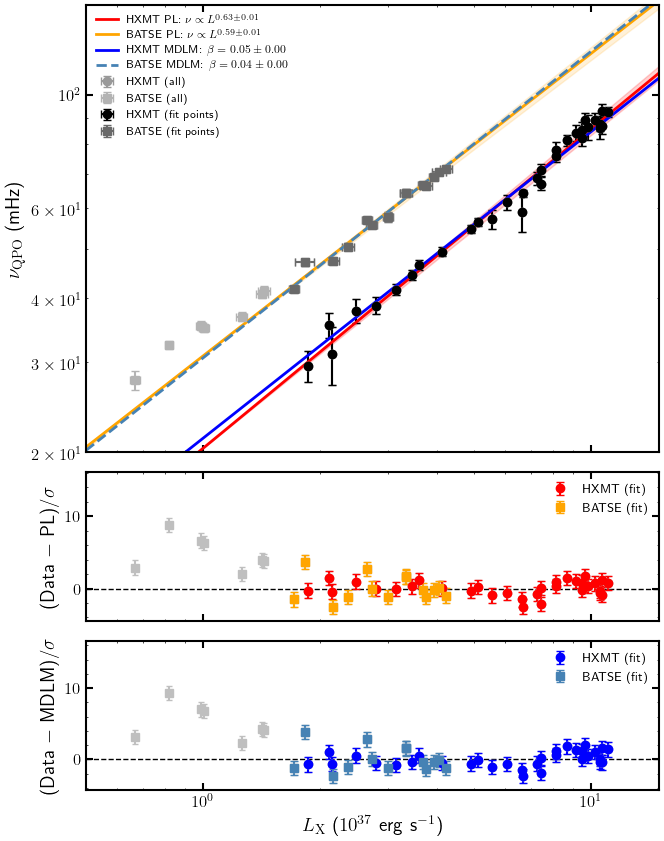

========== HXMT (fit range) ==========
Range: [None, None]  Nfit=32/32
PL:   K = 49.1740 ± 1.0939,  Gamma = 0.6250 ± 0.0119
MDLM: Beta = 0.05180 ± 0.00026
R2(PL)=0.9841,  chi2_red(PL)=1.050 (dof=30)
R2(MDLM)=0.9810, chi2_red(MDLM)=1.156 (dof=31)

========== BATSE (fit range) ==========
Range: [1.5, None]  Nfit=14/22
PL:   K = 32.4418 ± 0.4708,  Gamma = 0.5919 ± 0.0128
MDLM: Beta = 0.03607 ± 0.00013
R2(PL)=0.9809,  chi2_red(PL)=3.356 (dof=12)
R2(MDLM)=0.9801, chi2_red(MDLM)=3.129 (dof=13)


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# 0) 你需要提前准备两组数据（示例变量名）
#    x_hxmt, xerr_hxmt, y_hxmt, yerr_hxmt
#    x_hist, xerr_hist, y_hist, yerr_hist
# ============================================================

# ============================================================
# 1) 模型定义
# ============================================================
def f_power_fit(L37, K, Gamma):
    # 1000/(K*L^{-Gamma}) = (1000/K)*L^{Gamma}
    return 1000.0 / (K * L37**(-Gamma))

def f_kfm(L37, K):
    # KFM slope fixed at 3/7
    return 1000.0 / (K * L37**(-3/7))

# ---- MDLM (常数因子写法) ----
m = 1.4
R6 = 1.0
B12 = 5.4
Lambda = 0.1

A_factor = 12.0 * (Lambda**(-7/8)) * (m**(-13/20)) * (R6**(29/10)) * (B12**(3/2))

def f_mdlm(L37, Beta):
    return 1000.0 / (A_factor * Beta * L37**(-3/5))


# ============================================================
# 2) 拟合函数（带光度范围筛选）
# ============================================================
def fit_one_dataset(
    x, y, yerr,
    K_init=30.0, Gamma_init=0.6, Beta_init=0.01,
    Lmin=None, Lmax=None,
    return_mask=True
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    # --- selection mask ---
    mask = np.ones_like(x, dtype=bool)
    if Lmin is not None:
        mask &= (x >= Lmin)
    if Lmax is not None:
        mask &= (x <= Lmax)

    if mask.sum() < 3:
        raise ValueError(
            f"Too few points ({mask.sum()}) in selected range "
            f"[{Lmin}, {Lmax}]. Please widen the range."
        )
    if np.any(yerr[mask] <= 0):
        raise ValueError("yerr must be positive for all selected points.")

    x_fit = x[mask]
    y_fit = y[mask]
    yerr_fit = yerr[mask]

    # --- Power-law (K, Gamma) ---
    popt_pl, pcov_pl = curve_fit(
        f_power_fit, x_fit, y_fit,
        sigma=yerr_fit, absolute_sigma=True,
        p0=[K_init, Gamma_init],
        maxfev=20000
    )
    perr_pl = np.sqrt(np.diag(pcov_pl))

    # --- KFM (K only) ---
    popt_kfm, pcov_kfm = curve_fit(
        f_kfm, x_fit, y_fit,
        sigma=yerr_fit, absolute_sigma=True,
        p0=[K_init],
        maxfev=20000
    )
    perr_kfm = np.sqrt(np.diag(pcov_kfm))

    # --- MDLM (Beta only; Beta>0) ---
    popt_mdlm, pcov_mdlm = curve_fit(
        f_mdlm, x_fit, y_fit,
        sigma=yerr_fit, absolute_sigma=True,
        p0=[Beta_init],
        bounds=(1e-6, np.inf),
        maxfev=20000
    )
    perr_mdlm = np.sqrt(np.diag(pcov_mdlm))

    if return_mask:
        return (popt_pl, perr_pl), (popt_kfm, perr_kfm), (popt_mdlm, perr_mdlm), mask
    else:
        return (popt_pl, perr_pl), (popt_kfm, perr_kfm), (popt_mdlm, perr_mdlm)


# ============================================================
# 3) R^2 / chi2
# ============================================================
def chi2_red(y, yfit, yerr, npar):
    chi2 = np.sum(((y - yfit) / yerr)**2)
    dof = len(y) - npar
    return chi2 / dof, chi2, dof

def r_squared(y_obs, y_fit):
    ss_res = np.sum((y_obs - y_fit) ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    return 1 - (ss_res / ss_tot)


# ============================================================
# 4) 选择拟合范围（你只需要改这里）
#    None 表示不限制
# ============================================================
Lmin_hxmt, Lmax_hxmt = None, None   # 例如: 3.0, 12.0
Lmin_hist, Lmax_hist = 1.5, None   # 例如: 0.8, 4.5


# ============================================================
# 5) 运行拟合（两组独立 + 记录mask）
# ============================================================
(pl_hxmt, kfm_hxmt, mdlm_hxmt, mask_hxmt) = fit_one_dataset(
    x_hxmt, y_hxmt, yerr_hxmt,
    Lmin=Lmin_hxmt, Lmax=Lmax_hxmt
)
(K_hxmt, G_hxmt) = pl_hxmt[0]
(eK_hxmt, eG_hxmt) = pl_hxmt[1]
(Kk_hxmt,) = kfm_hxmt[0]
(eKk_hxmt,) = kfm_hxmt[1]
(B_hxmt,) = mdlm_hxmt[0]
(eB_hxmt,) = mdlm_hxmt[1]

(pl_hist, kfm_hist, mdlm_hist, mask_hist) = fit_one_dataset(
    x_hist, y_hist, yerr_hist,
    Lmin=Lmin_hist, Lmax=Lmax_hist
)
(K_hist, G_hist) = pl_hist[0]
(eK_hist, eG_hist) = pl_hist[1]
(Kk_hist,) = kfm_hist[0]
(eKk_hist,) = kfm_hist[1]
(B_hist,) = mdlm_hist[0]
(eB_hist,) = mdlm_hist[1]


# ============================================================
# 6) 准备拟合曲线（x轴范围仍用“全部数据”）
# ============================================================
xmin = min(np.min(x_hxmt), np.min(x_hist)) * 0.9
xmax = max(np.max(x_hxmt), np.max(x_hist)) * 1.05
print("Plot range:", xmin, xmax)
Lfit = np.linspace(0.5, 15, 2000)

pl_hxmt_fit   = f_power_fit(Lfit, K_hxmt, G_hxmt)
pl_hist_fit   = f_power_fit(Lfit, K_hist, G_hist)
mdlm_hxmt_fit = f_mdlm(Lfit, B_hxmt)
mdlm_hist_fit = f_mdlm(Lfit, B_hist)

def pl_gamma_band(L, K, G, eG):
    y_up = f_power_fit(L, K, G + eG)
    y_lo = f_power_fit(L, K, G - eG)
    return y_lo, y_up


# ============================================================
# 7) 残差：用全部点画，但“参与拟合的点”高亮（推荐）
# ============================================================
res_hxmt_pl_all   = (y_hxmt - f_power_fit(x_hxmt, K_hxmt, G_hxmt)) / yerr_hxmt
res_hist_pl_all   = (y_hist - f_power_fit(x_hist, K_hist, G_hist)) / yerr_hist
res_hxmt_mdlm_all = (y_hxmt - f_mdlm(x_hxmt, B_hxmt)) / yerr_hxmt
res_hist_mdlm_all = (y_hist - f_mdlm(x_hist, B_hist)) / yerr_hist


# ============================================================
# 8) 作图：三联图
# ============================================================
fig, axs = plt.subplots(
    3, 1, figsize=(7.4, 10.2),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1, 1]}
)

# ---------- Top panel ----------
axs[0].set_ylabel(r'$\nu_{\rm QPO}$ (mHz)')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(2e1, 1.5e2)
axs[0].set_xlim(0.5,15)
# 全部数据（浅色）
axs[0].errorbar(x_hxmt, y_hxmt, xerr=xerr_hxmt, yerr=yerr_hxmt,
               fmt='o', color='0.6', capsize=3, label='HXMT (all)')
axs[0].errorbar(x_hist, y_hist, xerr=xerr_hist, yerr=yerr_hist,
               fmt='s', color='0.7', capsize=3, label='BATSE (all)')

# 参与拟合的数据（深色高亮）
axs[0].errorbar(x_hxmt[mask_hxmt], y_hxmt[mask_hxmt],
               xerr=xerr_hxmt[mask_hxmt], yerr=yerr_hxmt[mask_hxmt],
               fmt='o', color='black', capsize=3, label='HXMT (fit points)')
axs[0].errorbar(x_hist[mask_hist], y_hist[mask_hist],
               xerr=xerr_hist[mask_hist], yerr=yerr_hist[mask_hist],
               fmt='s', color='dimgray', capsize=3, label='BATSE (fit points)')

# 拟合曲线
axs[0].plot(Lfit, pl_hxmt_fit, lw=2, color='red',
            label=rf'HXMT PL: $\nu\propto L^{{{G_hxmt:.2f}\pm{eG_hxmt:.2f}}}$')
axs[0].plot(Lfit, pl_hist_fit, lw=2, color='orange',
            label=rf'BATSE PL: $\nu\propto L^{{{G_hist:.2f}\pm{eG_hist:.2f}}}$')
axs[0].plot(Lfit, mdlm_hxmt_fit, lw=2, color='blue',
            label=rf'HXMT MDLM: $\beta={B_hxmt:.2f}\pm{eB_hxmt:.2f}$')
axs[0].plot(Lfit, mdlm_hist_fit, lw=2, color='steelblue', ls='--',
            label=rf'BATSE MDLM: $\beta={B_hist:.2f}\pm{eB_hist:.2f}$')

# PL Gamma 阴影
lo, up = pl_gamma_band(Lfit, K_hxmt, G_hxmt, eG_hxmt)
axs[0].fill_between(Lfit, lo, up, color='red', alpha=0.18)
lo, up = pl_gamma_band(Lfit, K_hist, G_hist, eG_hist)
axs[0].fill_between(Lfit, lo, up, color='orange', alpha=0.15)

axs[0].legend(loc='upper left', fontsize=8)

# ---------- Middle panel: PL residual ----------
axs[1].set_ylabel(r'(Data $-$ PL)/$\sigma$')
axs[1].set_xlim(0.5,15)
axs[1].axhline(0, color='k', ls='--', lw=1)

axs[1].errorbar(x_hxmt, res_hxmt_pl_all, yerr=np.ones_like(res_hxmt_pl_all),
                fmt='o', color='0.7', capsize=2)
axs[1].errorbar(x_hist, res_hist_pl_all, yerr=np.ones_like(res_hist_pl_all),
                fmt='s', color='0.75', capsize=2)

axs[1].errorbar(x_hxmt[mask_hxmt], res_hxmt_pl_all[mask_hxmt],
                yerr=np.ones_like(res_hxmt_pl_all[mask_hxmt]),
                fmt='o', color='red', capsize=3, label='HXMT (fit)')
axs[1].errorbar(x_hist[mask_hist], res_hist_pl_all[mask_hist],
                yerr=np.ones_like(res_hist_pl_all[mask_hist]),
                fmt='s', color='orange', capsize=3, label='BATSE (fit)')

# axs[1].set_ylim(-4, 4)
axs[1].legend(loc='upper right', fontsize=9)

# ---------- Bottom panel: MDLM residual ----------
axs[2].set_xlabel(r'$L_{\rm X}$ ($10^{37}$ erg s$^{-1}$)')
axs[2].set_ylabel(r'(Data $-$ MDLM)/$\sigma$')
axs[2].axhline(0, color='k', ls='--', lw=1)
axs[2].set_xlim(0.5,15)

axs[2].errorbar(x_hxmt, res_hxmt_mdlm_all, yerr=np.ones_like(res_hxmt_mdlm_all),
                fmt='o', color='0.7', capsize=2)
axs[2].errorbar(x_hist, res_hist_mdlm_all, yerr=np.ones_like(res_hist_mdlm_all),
                fmt='s', color='0.75', capsize=2)

axs[2].errorbar(x_hxmt[mask_hxmt], res_hxmt_mdlm_all[mask_hxmt],
                yerr=np.ones_like(res_hxmt_mdlm_all[mask_hxmt]),
                fmt='o', color='blue', capsize=3, label='HXMT (fit)')
axs[2].errorbar(x_hist[mask_hist], res_hist_mdlm_all[mask_hist],
                yerr=np.ones_like(res_hist_mdlm_all[mask_hist]),
                fmt='s', color='steelblue', capsize=3, label='BATSE (fit)')

# axs[2].set_ylim(-4, 4)
axs[2].legend(loc='upper right', fontsize=9)

plt.subplots_adjust(hspace=0.08)
plt.savefig('QPO_Lum_HXMT_BASTE_fit2.pdf')
plt.show()


# ============================================================
# 9) 打印拟合结果 + chi2_red / R2
#    注意：统计量也建议用“参与拟合点”计算（更一致）
# ============================================================
print("========== HXMT (fit range) ==========")
print(f"Range: [{Lmin_hxmt}, {Lmax_hxmt}]  Nfit={mask_hxmt.sum()}/{len(x_hxmt)}")
print(f"PL:   K = {K_hxmt:.4f} ± {eK_hxmt:.4f},  Gamma = {G_hxmt:.4f} ± {eG_hxmt:.4f}")
print(f"MDLM: Beta = {B_hxmt:.5f} ± {eB_hxmt:.5f}")

r2_hxmt_pl = r_squared(y_hxmt[mask_hxmt], f_power_fit(x_hxmt[mask_hxmt], K_hxmt, G_hxmt))
r2_hxmt_m  = r_squared(y_hxmt[mask_hxmt], f_mdlm(x_hxmt[mask_hxmt], B_hxmt))
chi2r_hxmt_pl, chi2_hxmt_pl, dof_hxmt_pl = chi2_red(
    y_hxmt[mask_hxmt], f_power_fit(x_hxmt[mask_hxmt], K_hxmt, G_hxmt), yerr_hxmt[mask_hxmt], npar=2
)
chi2r_hxmt_m, chi2_hxmt_m, dof_hxmt_m = chi2_red(
    y_hxmt[mask_hxmt], f_mdlm(x_hxmt[mask_hxmt], B_hxmt), yerr_hxmt[mask_hxmt], npar=1
)
print(f"R2(PL)={r2_hxmt_pl:.4f},  chi2_red(PL)={chi2r_hxmt_pl:.3f} (dof={dof_hxmt_pl})")
print(f"R2(MDLM)={r2_hxmt_m:.4f}, chi2_red(MDLM)={chi2r_hxmt_m:.3f} (dof={dof_hxmt_m})")

print("\n========== BATSE (fit range) ==========")
print(f"Range: [{Lmin_hist}, {Lmax_hist}]  Nfit={mask_hist.sum()}/{len(x_hist)}")
print(f"PL:   K = {K_hist:.4f} ± {eK_hist:.4f},  Gamma = {G_hist:.4f} ± {eG_hist:.4f}")
print(f"MDLM: Beta = {B_hist:.5f} ± {eB_hist:.5f}")

r2_hist_pl = r_squared(y_hist[mask_hist], f_power_fit(x_hist[mask_hist], K_hist, G_hist))
r2_hist_m  = r_squared(y_hist[mask_hist], f_mdlm(x_hist[mask_hist], B_hist))
chi2r_hist_pl, chi2_hist_pl, dof_hist_pl = chi2_red(
    y_hist[mask_hist], f_power_fit(x_hist[mask_hist], K_hist, G_hist), yerr_hist[mask_hist], npar=2
)
chi2r_hist_m, chi2_hist_m, dof_hist_m = chi2_red(
    y_hist[mask_hist], f_mdlm(x_hist[mask_hist], B_hist), yerr_hist[mask_hist], npar=1
)
print(f"R2(PL)={r2_hist_pl:.4f},  chi2_red(PL)={chi2r_hist_pl:.3f} (dof={dof_hist_pl})")
print(f"R2(MDLM)={r2_hist_m:.4f}, chi2_red(MDLM)={chi2r_hist_m:.3f} (dof={dof_hist_m})")

In [80]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('science')
plt.rcParams['text.usetex'] = True
#import seaborn; seaborn.set()
import astropy.io.fits as fits
from astropy.io import ascii
from astropy.table import Table
import scipy.stats as stats
import os
import re
from pandas import DataFrame
import pandas as pd
import sys
# 定义颜色
colors = {
    'red': '#E24A33',
    'blue': '#348ABD',
    'green': '#8EBA42',
    'orange': '#FBC15E',
    'purple': '#988ED5',
    'pink': '#FFB5B8',
    'gray': '#777777'
}
plt.rcParams.update({
    'font.size': 12,               # 字体大小
    'font.family': 'sans-serif',    # 字体类型
    'font.sans-serif': ['Arial'],   # 使用 Arial 字体
    'axes.linewidth': 1.5,          # 坐标轴线宽
    'axes.labelsize': 14,           # 坐标轴标签大小
    'axes.titlesize': 14,           # 标题字体大小
    'xtick.labelsize': 12,          # X轴刻度字体大小
    'ytick.labelsize': 12,          # Y轴刻度字体大小
    'xtick.major.size': 5,          # X轴主刻度长度
    'ytick.major.size': 5,          # Y轴主刻度长度
    'xtick.major.width': 1.5,       # X轴主刻度宽度
    'ytick.major.width': 1.5,       # Y轴主刻度宽度
    'legend.fontsize': 12,          # 图例字体大小
    'legend.frameon': False,        # 图例无边框
    'lines.linewidth': 1.5,         # 曲线的默认线宽
    'savefig.dpi': 300,             # 保存图片的分辨率
    'figure.figsize': (7, 5),       # 图形大小 (以英寸为单位)
    'figure.autolayout': False       # 自动调整布局
})

def readfile(tfile): 
    with open(tfile,'r') as f:
        lines=f.readlines()
    return lines
source="/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine_old/pds_xspec/fit_results"
path0="/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine_old/pds_xspec/fit_results"
files=os.listdir("%s"%source)

In [81]:
Models=['lorentz']
N_Units=[[1]]
errs=[5]
Long_index=[1]


In [82]:
def read_fitresults(source,files,Models,N_Unitsi,path0):
    print(files)
    #MJD = read_MJD(files,path0)
    f = open("%s/%s"%(source,files),"r")
    all=f.read()
    #print(all)
    line_tails=readfile("%s/%s"%(source,files))
    #print(line_tails)
    j=0
    pars_values=[]
    pars_names=[]
    while j < len(Models):
        pars=re.findall(r"%s.*"%Models[j], all)
        #print(pars)
        l=len(N_Units[j])
        while l > 0:
            p=N_Units[j][-l]
            if Long_index[j] > 1:
                pars_values.append(float(pars[-l-(Long_index[j]-1)*len(N_Units[j+1])].split()[2+p]))
                #print(pars_values)
                name_str=Models[j]+'%s'%Long_index[j]+'_'+pars[-l].split()[1]
                pars_names.append(name_str)
                l-=1
            else:
                pars_values.append(float(pars[-l].split()[2+p]))
                name_str=Models[j]+'%s'%Long_index[j]+'_'+pars[-l].split()[1]
                pars_names.append(name_str)
                l-=1
        j+=1
    par_chi=re.findall(r"Test statistic : Chi-Squared.*", all)
    #print(par_chi[-1].split())
    dofall=re.findall(r"Null hypothesis probability.*", all)
    #print(dofall[-1].split())
    chi2=par_chi[-1].split()[4]
    # print(chi2)
    dof=dofall[-1].split()[6]
    # print(dof)
    red_chi2=float(chi2)/float(dof)
    # print(red_chi2)
    return pars_names, pars_values, red_chi2

In [83]:
def read_errs(source,files,errs,pars_names,pars_values):
    f = open("%s/%s"%(source,files),"r")
    all=f.read()
    #print(all)
    line_tails=readfile("%s/%s"%(source,files))
    Err=re.findall(r"Parameter   Credible Interval.*", all)
    l=0
    while l < len(line_tails):
        if Err[0] in line_tails[l]:
            L=l
        else:
            pass
        l+=1
    for e in errs:
        Errs_results=[line_tails[L+1+a].split() for a in range(len(errs))]
    pars_Err_lh=[]
    NE=0
    while NE < len(errs):
        err_low=float(Errs_results[NE][1])
        err_high=float(Errs_results[NE][2])
        pars_Err_lh.append([err_low,err_high])
        NE+=1
    #print(pars_values)
    #get err
    Np=0
    err_LR=[]
    while Np < len(pars_values):
        err_L=pars_values[Np]-pars_Err_lh[Np][0]
        err_R=pars_Err_lh[Np][1]-pars_values[Np]
        err_LR.append([err_L,err_R])
        Np+=1
    err_names_L=["%s_Lerrs"%Name for Name in pars_names]
    err_names_R=["%s_Rerrs"%Name for Name in pars_names]

    err_L=[i[0] for i in err_LR]
    err_R=[i[1] for i in err_LR]

    return err_names_L,err_L,err_names_R,err_R

In [84]:
Obsid = ['20201214','20201213','20201212','20201211','20201210',
         '20201209','20201208','20201207','20201205',
         '20201204','20201203','20201202','20201201','20201130',
         '20201129','20201128','20201127','20201126','20201125',
         '20201124','20201122','20201121','20201120','20201119',
         '20201117','20201116','20201115','20201114']
x = np.array([2.12, 2.48, 2.8, 3.15, 3.45,
              3.61, 4.12, 4.91, 5.1,
              6.08, 6.69, 7.25, 7.43, 7.44, 
              8.11, 8.69, 9.14, 9.5, 9.67, 
              9.84, 10.55, 10.54, 11.04, 10.69, 
              10.24, 9.46, 8.1, 6.65])
i=0
red_chi2_all=[]
while i < len(Obsid):
    files=f"{Obsid[i]}.txt"
#while i < 1:
    #pars_names, pars_values,red_chi2,dof, MJD, Lum, Lum_errL, Lum_errR=read_fitresults(source,files[i],Models,N_Units,path0)
    pars_names, pars_values, red_chi2=read_fitresults(source,files,Models, N_Units,path0)
    red_chi2_all.append(red_chi2)
    #print(red_chi2)
    #print(pars_names)
    fit_names=pars_names
    fit_data=pars_values

    err_names_L, err_L, err_names_R, err_R=read_errs(source,files,errs,pars_names,pars_values)
    #print(err_names_L)
    #err_names_L, err_L = err_names_L+['Lum_errL'], err_L+[Lum_errL]
    #err_names_R, err_R = err_names_R+['Lum_errR'], err_R+[Lum_errR]
    
    derr_L=dict(zip(err_names_L,err_L))
    derr_R=dict(zip(err_names_R,err_R))
    if i==0:
        d1 = dict(zip(fit_names,fit_data))
        Para=pd.DataFrame(d1,index=['%s'%files])
        Para_errL=pd.DataFrame(derr_L,index=['%s'%files])
        Para_errR=pd.DataFrame(derr_R,index=['%s'%files])
        i+=1
    else:
        Para.loc['%s'%files]=fit_data
        Para_errL.loc['%s'%files]=err_L
        Para_errR.loc['%s'%files]=err_R
        i+=1
Para_all=pd.concat([Para,Para_errL,Para_errR],axis=1)
#save_data="fit_comptt_final.csv"
#Para_all.to_csv(save_data)

20201214.txt
20201213.txt
20201212.txt
20201211.txt
20201210.txt
20201209.txt
20201208.txt
20201207.txt
20201205.txt
20201204.txt
20201203.txt
20201202.txt
20201201.txt
20201130.txt
20201129.txt
20201128.txt
20201127.txt
20201126.txt
20201125.txt
20201124.txt
20201122.txt
20201121.txt
20201120.txt
20201119.txt
20201117.txt
20201116.txt
20201115.txt
20201114.txt


In [85]:
print(Para_all.columns)
M=len(errs)
print(M)
names=Para_all.columns[:M]
print(names)

Index(['lorentz1_Width', 'lorentz1_Width_Lerrs', 'lorentz1_Width_Rerrs'], dtype='object')
1
Index(['lorentz1_Width'], dtype='object')


In [86]:
# y1=Para_all['bkn2pow1_BreakE2'].values
# y1_err=[abs(Para_all['bkn2pow1_BreakE2_Lerrs'].values),abs(Para_all['bkn2pow1_BreakE2_Rerrs'].values)]
# y1_err_mean = (abs(Para_all['bkn2pow1_BreakE2_Lerrs'].values)+abs(Para_all['bkn2pow1_BreakE2_Rerrs'].values))/2.

y1=Para_all['lorentz1_Width'].values
y1_err=[abs(Para_all['lorentz1_Width_Lerrs'].values),abs(Para_all['lorentz1_Width_Rerrs'].values)]
y1_err_mean = (abs(Para_all['lorentz1_Width_Lerrs'].values)+abs(Para_all['lorentz1_Width_Rerrs'].values))/2.


In [87]:
Para_all

,lorentz1_Width,lorentz1_Width_Lerrs,lorentz1_Width_Rerrs
20201214.txt,1.08193,0.124761,0.18356
20201213.txt,1.36802,0.061380,0.22825
20201212.txt,5.02020,1.077270,1.42816
20201211.txt,1.53392,0.124100,0.13601
20201210.txt,1.64003,0.089970,0.43985
20201209.txt,4.35571,0.645460,0.70552
20201208.txt,4.99278,1.069420,1.89625
20201207.txt,3.47201,0.324490,0.41331
20201205.txt,3.76618,0.291370,0.42772
20201204.txt,3.85182,0.310940,0.31277


In [112]:
# =========================
# 第一组数据：digitized QPO
# =========================
# data = np.array([
#     # [0.99e-09, 0.026, 0.003],
#     [4.0e-9, 0.065, 0.004],
#     [4.8e-9, 0.065, 0.004],
#     [5.4e-9, 0.070, 0.003],
#     [5.9e-9, 0.071, 0.003],
#     [7.4e-9, 0.083, 0.004],
#     [7.8e-9, 0.085, 0.004],
#     [8.0e-9, 0.080, 0.005],
#     [8.2e-9, 0.085, 0.004],
#     [8.4e-9, 0.087, 0.004],
#     [8.5e-9, 0.083, 0.005],
#     [8.6e-9, 0.089, 0.004],
#     [8.8e-9, 0.080, 0.005],
#     [8.8e-9, 0.086, 0.004],
#     [9.1e-9, 0.091, 0.004],
#     [9.2e-9, 0.086, 0.004],
#     [9.4e-9, 0.089, 0.004],
#     [9.6e-9, 0.086, 0.004],
# ])
import numpy as np

data = np.array([
    # flux        nu_qpo    nu_err

    # --- 低流量（三角形） ---
    [4.10e-9, 0.0645, 0.0100],
    [4.90e-9, 0.0650, 0.0060],
    [5.60e-9, 0.0700, 0.0045],
    [6.00e-9, 0.0710, 0.0035],

    # --- 中高流量（方块） ---
    [7.60e-9, 0.0830, 0.0040],
    [7.90e-9, 0.0850, 0.0040],
    [8.30e-9, 0.0845, 0.0045],
    [8.40e-9, 0.0885, 0.0050],
    [8.60e-9, 0.0865, 0.0045],

    # --- 高流量（三角形） ---
    [8.10e-9, 0.0790, 0.0070],
    [8.60e-9, 0.0825, 0.0075],
    [8.70e-9, 0.0795, 0.0020],
    [9.00e-9, 0.0905, 0.0070],

    # --- 最高流量（实心圆） ---
    [9.20e-9, 0.0855, 0.0055],
    [9.40e-9, 0.0888, 0.0040],
    [9.50e-9, 0.0860, 0.0045],
])

flux  = data[:, 0]
v_qpo = data[:, 1]
v_err = data[:, 2]

# 距离
d_kpc = 5.0
d_cm  = d_kpc * 3.086e21

luminosity = 4 * np.pi * d_cm**2 * flux

x1 = luminosity / 1e37
y1 = v_qpo * 1000.0
y1_err = v_err * 1000.0

x2 = x_hxmt
y2 = y_hxmt
y2_err = y_err_hxmt


=== RXTE/PCA 1A1118-615 (2009) ===
Fixed Γ=3/5:  K=47.7518 ± 0.63 | redχ²=1.109
Free Γ:       K=57.5038 ± 4.1, Γ=0.392103 ± 0.079 | redχ²=0.723
Δχ² = 6.515 (Δdof=1), p = 0.0107

=== HXMT/HE 1A0535+262 (2020) ===
Fixed Γ=3/5:  K=21.2769 ± 0.11 | redχ²=1.156
Free Γ:       K=20.3359 ± 0.45, Γ=0.625041 ± 0.012 | redχ²=1.050
Δχ² = 4.358 (Δdof=1), p = 0.0368

=== BATSE 1A0535+262 (1994) ===
Fixed Γ=3/5:  K=31.2408 ± 0.1 | redχ²=20.953
Free Γ:       K=34.5172 ± 0.22, Γ=0.492061 ± 0.0064 | redχ²=9.023
Δχ² = 259.544 (Δdof=1), p = 0


/var/folders/qk/mwf7_stn5yz6w8__49gqyhf40000gn/T/ipykernel_85997/240086043.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


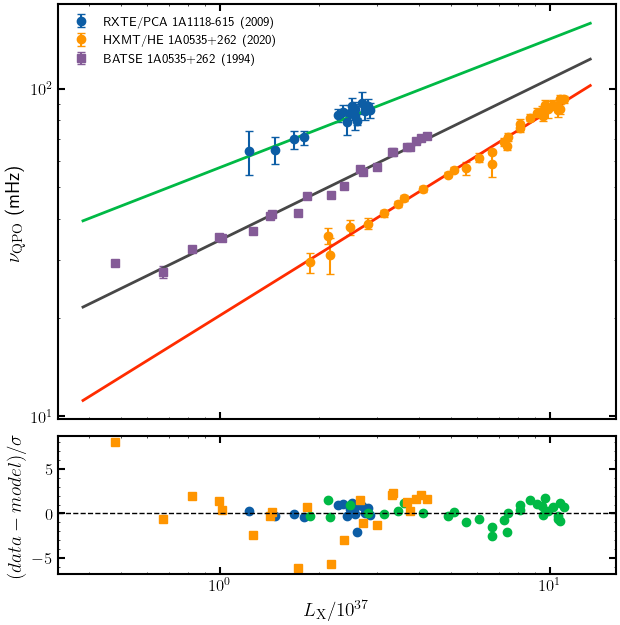

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# ============================================================
# 1) 两种模型：固定 Γ=3/5 与 Γ 自由
# ============================================================
def model_fix(L37, K):
    return K * L37**(3/5)

def model_free(L37, K, Gamma):
    return K * L37**Gamma


# ============================================================
# 2) 拟合函数：对每组数据同时做两次拟合（fix + free）
# ============================================================
def fit_both(x, y, yerr, name=""):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    yerr = np.asarray(yerr, float)

    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (x > 0) & (yerr > 0)
    x, y, yerr = x[m], y[m], yerr[m]
    if len(x) < 3:
        raise ValueError(f"{name}: valid points < 3")

    # ---- fixed Γ=3/5 ----
    p0_fix = (np.median(y / (x**(3/5))),)
    popt_fix, pcov_fix = curve_fit(
        model_fix, x, y, sigma=yerr, absolute_sigma=True, p0=p0_fix, maxfev=20000
    )
    yhat_fix = model_fix(x, *popt_fix)
    res_fix = (y - yhat_fix) / yerr
    chi2_fix = np.sum(res_fix**2)
    dof_fix = len(y) - len(popt_fix)
    rchi2_fix = chi2_fix / dof_fix if dof_fix > 0 else np.nan

    # ---- free Γ ----
    p0_free = (np.median(y / (x**0.6)), 0.6)
    popt_free, pcov_free = curve_fit(
        model_free, x, y, sigma=yerr, absolute_sigma=True, p0=p0_free, maxfev=20000
    )
    yhat_free = model_free(x, *popt_free)
    res_free = (y - yhat_free) / yerr
    chi2_free = np.sum(res_free**2)
    dof_free = len(y) - len(popt_free)
    rchi2_free = chi2_free / dof_free if dof_free > 0 else np.nan

    # Δχ2（Δdof=1）
    dchi2 = chi2_fix - chi2_free
    pval = 1 - chi2.cdf(dchi2, df=1) if dchi2 >= 0 else np.nan

    # 参数误差
    K_fix = popt_fix[0]
    K_fix_err = np.sqrt(np.diag(pcov_fix))[0]

    K_free, G_free = popt_free
    K_free_err, G_free_err = np.sqrt(np.diag(pcov_free))

    print(f"\n=== {name} ===")
    print(f"Fixed Γ=3/5:  K={K_fix:.6g} ± {K_fix_err:.2g} | redχ²={rchi2_fix:.3f}")
    print(f"Free Γ:       K={K_free:.6g} ± {K_free_err:.2g}, Γ={G_free:.6g} ± {G_free_err:.2g} | redχ²={rchi2_free:.3f}")
    print(f"Δχ² = {dchi2:.3f} (Δdof=1), p = {pval:.3g}")

    return dict(
        name=name,
        x=x, y=y, yerr=yerr,
        popt_fix=popt_fix, pcov_fix=pcov_fix, res_fix=res_fix,
        popt_free=popt_free, pcov_free=pcov_free, res_free=res_free,
        chi2_fix=chi2_fix, chi2_free=chi2_free,
        rchi2_fix=rchi2_fix, rchi2_free=rchi2_free,
        dchi2=dchi2, pval=pval
    )


# ============================================================
# 3) 你需要先准备三组数据：x1,y1,y1_err / x2,y2,y2_err / x3,y3,y3_err
#    这里假设它们已经存在（来自你前面的代码）
# ============================================================
# x1,y1,y1_err = ...
# x2,y2,y2_err = ...
# x3,y3,y3_err = ...

r1 = fit_both(x1, y1, y1_err, name="RXTE/PCA 1A1118-615 (2009)")
r2 = fit_both(x2, y2, y2_err, name="HXMT/HE 1A0535+262 (2020)")
r3 = fit_both(x3, y3, y3_err, name="BATSE 1A0535+262 (1994)")

results = [r1, r2, r3]


# ============================================================
# 4) 画在“一张图”上：
#    - 上：三组数据 + 三条拟合曲线（默认画 free Γ 的曲线；可选同时画 fixed Γ）
#    - 下：残差（分别三组数据的 residual）
# ============================================================
PLOT_BOTH_MODELS = False   # True：同时画 fixed(虚线) 和 free(实线)；False：只画 free(实线)
USE_FREE_FOR_RESIDUAL = True  # residual 用 free Γ（推荐）；False 用 fixed Γ

# 统一的拟合曲线横轴范围（覆盖三组数据）
xmin = min([np.min(r["x"]) for r in results]) * 0.8
xmax = max([np.max(r["x"]) for r in results]) * 1.2
xmin = max(xmin, 1e-6)
xfit = np.logspace(np.log10(xmin), np.log10(xmax), 400)

fig = plt.figure(figsize=(7.2, 7.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.06)
ax = fig.add_subplot(gs[0])
rx = fig.add_subplot(gs[1], sharex=ax)

# 给三组数据设置不同 marker（颜色不指定，由 matplotlib 自动循环）
styles = [
    dict(marker='o', ls='None', label=r1["name"]),
    dict(marker='o', ls='None', label=r2["name"]),
    dict(marker='s', ls='None', label=r3["name"]),
]

for r, st in zip(results, styles):
    # ---- 数据 ----
    ax.errorbar(r["x"], r["y"], yerr=r["yerr"], fmt=st["marker"], capsize=3, linestyle='None', label=st["label"])

    # ---- 拟合曲线 ----
    yfit_free = model_free(xfit, *r["popt_free"])
    ax.plot(xfit, yfit_free, linewidth=2)  # free Γ（实线）

    if PLOT_BOTH_MODELS:
        yfit_fix = model_fix(xfit, *r["popt_fix"])
        ax.plot(xfit, yfit_fix, linestyle='--', linewidth=1.6)  # fixed Γ（虚线）

    # ---- residual（只画三组数据的残差）----
    if USE_FREE_FOR_RESIDUAL:
        res = r["res_free"]
        mk = st["marker"]
    else:
        res = r["res_fix"]
        mk = st["marker"]

    rx.plot(r["x"], res, mk, linestyle='None')

# 上图轴设置
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$\nu_{\rm QPO}$ (mHz)')
ax.legend(fontsize=9)
ax.tick_params(labelbottom=False)

# 下图 residual
rx.axhline(0, color='k', linestyle='--', linewidth=1)
rx.set_xscale('log')
rx.set_xlabel(r'$L_{\rm X}/10^{37}$')
rx.set_ylabel(r'$(data-model)/\sigma$')

plt.tight_layout()
plt.savefig("QPO_all_in_one_fit_and_residual.pdf")
plt.show()


=== RXTE/PCA 1A1118-615 (2009) ===
Fixed Γ=3/5:  K=47.7518 ± 0.63 | dχ²=16.640
Free Γ:       K=57.5038 ± 4.1, Γ=0.392103 ± 0.079 | dχ²=10.126
Fixed redχ² = 1.109
Free  redχ² = 0.723
Δχ² = 6.515 (Δdof=1), p = 0.0107

=== HXMT/HE 1A0535+262 (2020) ===
Fixed Γ=3/5:  K=21.2769 ± 0.11 | dχ²=35.846
Free Γ:       K=20.3359 ± 0.45, Γ=0.625041 ± 0.012 | dχ²=31.488
Fixed redχ² = 1.156
Free  redχ² = 1.050
Δχ² = 4.358 (Δdof=1), p = 0.0368


/var/folders/qk/mwf7_stn5yz6w8__49gqyhf40000gn/T/ipykernel_85997/1668023711.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


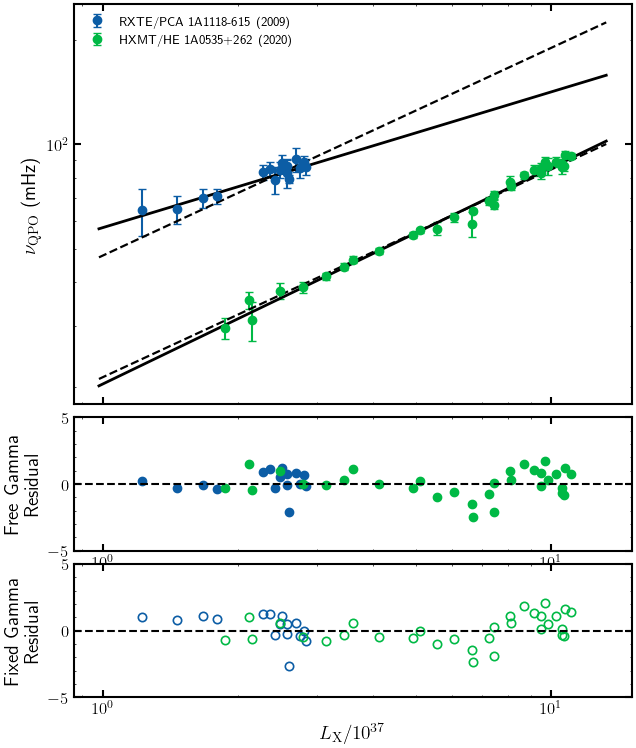

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# ============================================================
# Models
# ============================================================
def model_fix(L37, K):
    return K * L37**(3/5)

def model_free(L37, K, Gamma):
    return K * L37**Gamma


# ============================================================
# Fit function
# ============================================================
def fit_both(x, y, yerr, name=""):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    yerr = np.asarray(yerr, float)

    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (x > 0) & (yerr > 0)
    x, y, yerr = x[m], y[m], yerr[m]

    # ---- fixed Γ=3/5 ----
    p0_fix = (np.median(y / (x**(3/5))),)
    popt_fix, pcov_fix = curve_fit(
        model_fix, x, y, sigma=yerr, absolute_sigma=True, p0=p0_fix, maxfev=20000
    )
    yhat_fix = model_fix(x, *popt_fix)
    res_fix = (y - yhat_fix) / yerr
    chi2_fix = np.sum(res_fix**2)
    dof_fix = len(y) - len(popt_fix)

    # ---- free Γ ----
    p0_free = (np.median(y / (x**0.6)), 0.6)
    popt_free, pcov_free = curve_fit(
        model_free, x, y, sigma=yerr, absolute_sigma=True, p0=p0_free, maxfev=20000
    )
    yhat_free = model_free(x, *popt_free)
    res_free = (y - yhat_free) / yerr
    chi2_free = np.sum(res_free**2)
    dof_free = len(y) - len(popt_free)

    dchi2 = chi2_fix - chi2_free
    pval = 1 - chi2.cdf(dchi2, df=1)

    # 参数误差
    K_fix = popt_fix[0]
    K_fix_err = np.sqrt(np.diag(pcov_fix))[0]

    K_free, G_free = popt_free
    K_free_err, G_free_err = np.sqrt(np.diag(pcov_free))

    print(f"\n=== {name} ===")
    print(f"Fixed Γ=3/5:  K={K_fix:.6g} ± {K_fix_err:.2g} | dχ²={chi2_fix:.3f}")
    print(f"Free Γ:       K={K_free:.6g} ± {K_free_err:.2g}, Γ={G_free:.6g} ± {G_free_err:.2g} | dχ²={chi2_free:.3f}")
    print(f"Fixed redχ² = {chi2_fix/dof_fix:.3f}")
    print(f"Free  redχ² = {chi2_free/dof_free:.3f}")
    print(f"Δχ² = {dchi2:.3f} (Δdof=1), p = {pval:.3g}")

    return dict(
        name=name,
        x=x, y=y, yerr=yerr,
        popt_fix=popt_fix,
        popt_free=popt_free,
        res_fix=res_fix,
        res_free=res_free
    )


# ============================================================
# FIT THREE DATASETS (确保已定义 x1,x2,x3 等)
# ============================================================
r1 = fit_both(x1, y1, y1_err, "RXTE/PCA 1A1118-615 (2009)")
r2 = fit_both(x2, y2, y2_err, "HXMT/HE 1A0535+262 (2020)")
# r3 = fit_both(x3, y3, y3_err, "BATSE 1A0535+262 (1994)")
results = [r1, r2]

# ============================================================
# Plot: 3 panels
# ============================================================
xmin = min(np.min(r["x"]) for r in results) * 0.8
xmax = max(np.max(r["x"]) for r in results) * 1.2
xfit = np.logspace(np.log10(xmin), np.log10(xmax), 400)

fig = plt.figure(figsize=(7.2, 9))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 1], hspace=0.06)

ax = fig.add_subplot(gs[0])
ax_free = fig.add_subplot(gs[1], sharex=ax)
ax_fix = fig.add_subplot(gs[2], sharex=ax)

styles = [
    dict(marker='o', label=r1["name"]),
    dict(marker='o', label=r2["name"]),
    dict(marker='s', label=r3["name"]),
]

for r, st in zip(results, styles):
    mk = st["marker"]

    # ----- TOP PANEL: data + both fits -----
    ax.errorbar(r["x"], r["y"], yerr=r["yerr"],
                fmt=mk, linestyle='None', capsize=3,
                label=st["label"])

    ax.plot(xfit, model_free(xfit, *r["popt_free"]), linewidth=2, color='black')
    ax.plot(xfit, model_fix(xfit, *r["popt_fix"]), linestyle='--', linewidth=1.6, color='black')

    # ----- MIDDLE: free residual -----
    ax_free.plot(r["x"], r["res_free"], mk, linestyle='None')
    ax_free.set_ylim(-5, 5)

    # ----- BOTTOM: fixed residual -----
    ax_fix.plot(r["x"], r["res_fix"], mk,
                linestyle='None',
                markerfacecolor='none',
                markeredgewidth=1.2)
    ax_fix.set_ylim(-5, 5)
    

# -------- Axis formatting --------
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$\nu_{\rm QPO}$ (mHz)')
ax.legend(fontsize=9)
ax.tick_params(labelbottom=False)

ax_free.axhline(0, color='k', linestyle='--')
ax_free.set_xscale('log')
ax_free.set_ylabel('Free Gamma\nResidual')

ax_fix.axhline(0, color='k', linestyle='--')
ax_fix.set_xscale('log')
ax_fix.set_xlabel(r'$L_{\rm X}/10^{37}$')
ax_fix.set_ylabel('Fixed Gamma\nResidual')

plt.tight_layout()
plt.savefig("QPO_comparation.pdf")
plt.show()

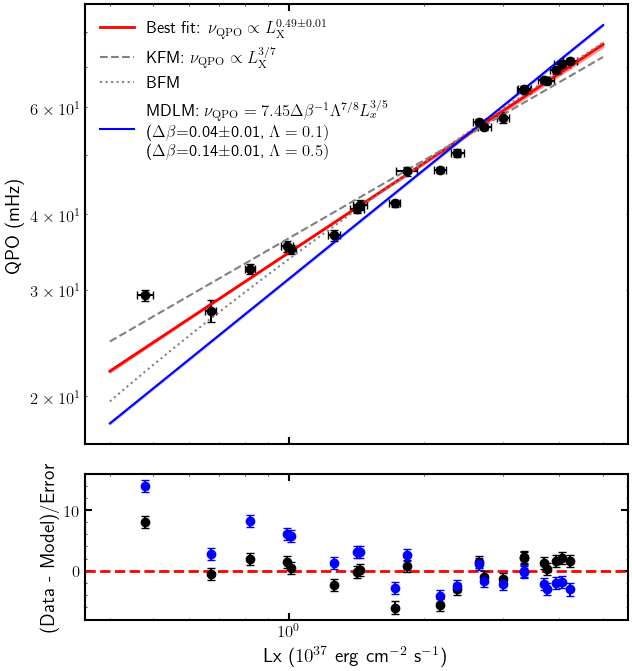

拟合得到的 K 值: 28.9710 ± 0.1881
拟合得到的 Gamma 值: 0.4921 ± 0.0064
拟合得到的 K1 值: 27.4296 ± 0.0879
拟合得到的 Beta 值: 0.0353 ± 0.0001
r2_power 拟合的 R² 值: 0.9817
r2_r 拟合的 R² 值: 0.9526


In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
# 计算 L37 (转换为 10^37 erg/s)
L37 = x_baste

# 定义 t_th 拟合函数 (alpha 作为拟合参数)
def f_power_fit(L37, K, Gamma):
    return 1000 / (K * L37 ** (-Gamma))

def f_power_fit1(L37, K):
    return 1000 / (K * L37 ** (-3/7))

def f_power_fit2(L37, K):
    return 1000 / (K * L37 ** (-3/7))-9.67

def f_power_fit3(L37, K):
    return 1000 / (K * L37 ** (-0.55))

# 定义 t_r 拟合函数 (Beta 作为拟合参数)
def f_r_fit(L37, Beta):
    return 1000 / (12 * Beta * Lambda**(-7/8) * m**(-13/20) * R6**(29/10) * B12**(3/2) * L37**(-3/5))

# def f_r_fit(L37, Beta):
#     return 7.45* Beta**(-1) * Lambda**(7/8) * L37**(3/5)


# 初始参数
Beta_init = 0.01
Gamma_init = 0.6
K_init = 30
Lambda = 0.1

# 拟合 f_power_fit
popt_power, pcov_power = curve_fit(f_power_fit, L37, y_baste, sigma=y_err_baste, absolute_sigma=True, p0=[K_init, Gamma_init])
K_opt, Gamma_opt = popt_power
perr_power = np.sqrt(np.diag(pcov_power))  # 参数误差

# 拟合 f_power_fit1
popt_power1, pcov_power1 = curve_fit(f_power_fit1, L37, y_baste, sigma=y_err_baste, absolute_sigma=True, p0=[K_init])
K1_opt = popt_power1[0]
perr_power1 = np.sqrt(np.diag(pcov_power1))

# 拟合 f_power_fit2
popt_power2, pcov_power2 = curve_fit(f_power_fit2, L37, y_baste, sigma=y_err_baste, absolute_sigma=True, p0=[K_init])
K2_opt = popt_power2[0]
perr_power2 = np.sqrt(np.diag(pcov_power2))

# 拟合 f_power_fit3
popt_power3, pcov_power3 = curve_fit(f_power_fit3, L37, y_baste, sigma=y_err_baste, absolute_sigma=True, p0=[K_init])
K3_opt = popt_power3[0]
perr_power3 = np.sqrt(np.diag(pcov_power3))

# 拟合 f_r_fit
popt_r, pcov_r = curve_fit(f_r_fit, L37, y_baste, sigma=y_err_baste, absolute_sigma=True, p0=[Beta_init])
Beta_opt = popt_r[0]
perr_r = np.sqrt(np.diag(pcov_r))

# 计算拟合曲线
L37_fit = np.linspace(0.4, 5, 1000)


f_power_fit_values = f_power_fit(L37_fit, K_opt, Gamma_opt)
f_power_fit1_values = f_power_fit1(L37_fit, K1_opt)
f_power_fit2_values = f_power_fit2(L37_fit, K2_opt)
f_power_fit3_values = f_power_fit3(L37_fit, K3_opt)
f_r_fit_values = f_r_fit(L37_fit, Beta_opt)

# 计算残差
residuals_power = (y_baste - f_power_fit(L37, K_opt, Gamma_opt)) / y_err_baste
residuals_power1 = (y_baste - f_power_fit1(L37, K1_opt)) / y_err_baste
residuals_power2 = (y_baste - f_power_fit2(L37, K2_opt)) / y_err_baste
residuals_power3 = (y_baste - f_power_fit3(L37, K3_opt)) / y_err_baste
residuals_r = (y_baste - f_r_fit(L37, Beta_opt)) / y_err_baste

# 计算 R² 值
def r_squared(y_obs, y_fit):
    ss_res = np.sum((y_obs - y_fit) ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_power = r_squared(y_baste, f_power_fit(L37, K_opt, Gamma_opt))
r2_power1 = r_squared(y_baste, f_power_fit1(L37, K1_opt))
r2_power2 = r_squared(y_baste, f_power_fit2(L37, K2_opt))
r2_power3 = r_squared(y_baste, f_power_fit3(L37, K3_opt))
r2_r = r_squared(y_baste, f_r_fit(L37, Beta_opt))

# 创建子图
fig, axs = plt.subplots(2, 1, figsize=(7, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
#axs[0].set_xscale('log')
#axs[0].set_yscale('log')
axs[0].set_ylabel(r'QPO (mHz)')
#axs[0].set_title(r'Luminosity vs. QPO')

# axs[1].set_xscale('log')
axs[1].set_xlabel(r'Lx ($10^{37}$ erg cm$^{-2}$ s$^{-1}$)')
axs[1].set_ylabel("(Data - Model)/Error")

# 第一张子图: 拟合曲线

axs[0].errorbar(x_baste, y_baste,xerr=x_err_baste, yerr=y_err_baste, fmt='o', color='black', capsize=3)
axs[0].plot(L37_fit, f_power_fit_values, label=r"Best fit: $\nu_{\rm QPO}\propto L_{\rm X}^{%0.2f\pm%0.2f}$"%(Gamma_opt,perr_power[1]), color='red',lw=2)
axs[0].plot(L37_fit, f_power_fit1_values, label=r"KFM: $\nu_{\rm QPO}\propto L_{\rm X}^{3/7}$", color='gray',ls='--')
axs[0].plot(L37_fit, f_power_fit2_values, label=r"BFM", color='gray',ls=':')
#axs[0].plot(L37_fit, f_power_fit3_values, label=r"MDPM: $\nu_{\rm QPO}\propto L_{x}^{0.55}}$", color='green')
axs[0].plot(L37_fit, f_r_fit_values, 
            label=r"MDLM: $\nu_{\rm QPO} =  7.45\Delta\beta^{-1}\Lambda^{7/8} L_{x}^{3/5}$"+"\n" +r"($\Delta \beta$=%.2f±0.01, $\Lambda=0.1)$"%Beta_opt+"\n" + r"($\Delta \beta$=0.14±0.01, $\Lambda=0.5)$", 
            color='blue')
# ===== Beta 不确定性阴影（MDLM）=====

Beta_upper = Beta_opt + perr_r[0]
Beta_lower = Beta_opt - perr_r[0]

# 注意：beta 在分母里，upper/lower 会反过来
fit_r_upper = f_r_fit(L37_fit, Beta_lower)  # beta 小 → 频率大
fit_r_lower = f_r_fit(L37_fit, Beta_upper)  # beta 大 → 频率小

axs[0].fill_between(
    L37_fit,
    fit_r_lower,
    fit_r_upper,
    color='blue',
    alpha=0.25
)

# 计算误差上下界对应的拟合曲线
Gamma_upper = Gamma_opt + perr_power[1]
Gamma_lower = Gamma_opt - perr_power[1]

fit_upper = f_power_fit(L37_fit, K_opt, Gamma_upper)
fit_lower = f_power_fit(L37_fit, K_opt, Gamma_lower)

# 添加拟合曲线误差阴影区域
axs[0].fill_between(L37_fit, fit_lower, fit_upper, color='red', alpha=0.3)


axs[0].legend(loc='upper left')
axs[0].set_xscale('log')
axs[0].set_yscale('log')



#axs[0].set_xlim(1.7,11.5)
# 第二张子图: 残差
axs[1].axhline(0, color='red', linestyle='--', linewidth=2)
axs[1].errorbar(x_baste, residuals_power, yerr=y_err_baste/y_err_baste, fmt='o', color='black',capsize=3)
# axs[1].errorbar(x, residuals_power1, yerr=y_err/y_err, fmt='o', color='gray',capsize=3)
# axs[1].errorbar(x, residuals_power2, yerr=y_err/y_err, fmt='o', color='gray',capsize=3)
# axs[1].errorbar(x, residuals_power3, yerr=y_err/y_err, fmt='o', color='green',capsize=3)
axs[1].errorbar(x_baste, residuals_r, yerr=y_err_baste/y_err_baste, fmt='o', color='blue',capsize=3)
#axs[1].errorbar(x[24:], residuals_r[24:], yerr=y_err[24:]/y_err[24:], fmt='s', color='green', capsize=3)
#axs[1].set_ylim(-3.5,3.5)
axs[1].set_xscale('log')
#plt.tight_layout()




from matplotlib.ticker import LogLocator, ScalarFormatter

# axs[0].xaxis.set_major_locator(LogLocator(base=10, subs=[2, 3, 4, 6, 10]))
# axs[0].xaxis.set_major_formatter(ScalarFormatter())

# axs[0].yaxis.set_major_locator(LogLocator(base=10, subs=[30, 40, 60, 80, 100]))
# axs[0].yaxis.set_major_formatter(ScalarFormatter())

# axs[0].set_xlim(1.5,15)
# axs[1].set_xlim(1.5,15)
#plt.tight_layout
plt.subplots_adjust(wspace=0, hspace=0.1)
#plt.savefig('QPO_Lum_modelfit_new.pdf')
plt.show()

# 输出拟合结果
print(f"拟合得到的 K 值: {K_opt:.4f} ± {perr_power[0]:.4f}")
print(f"拟合得到的 Gamma 值: {Gamma_opt:.4f} ± {perr_power[1]:.4f}")
print(f"拟合得到的 K1 值: {K1_opt:.4f} ± {perr_power1[0]:.4f}")
print(f"拟合得到的 Beta 值: {Beta_opt:.4f} ± {perr_r[0]:.4f}")
print(f"r2_power 拟合的 R² 值: {r2_power:.4f}")
print(f"r2_r 拟合的 R² 值: {r2_r:.4f}")




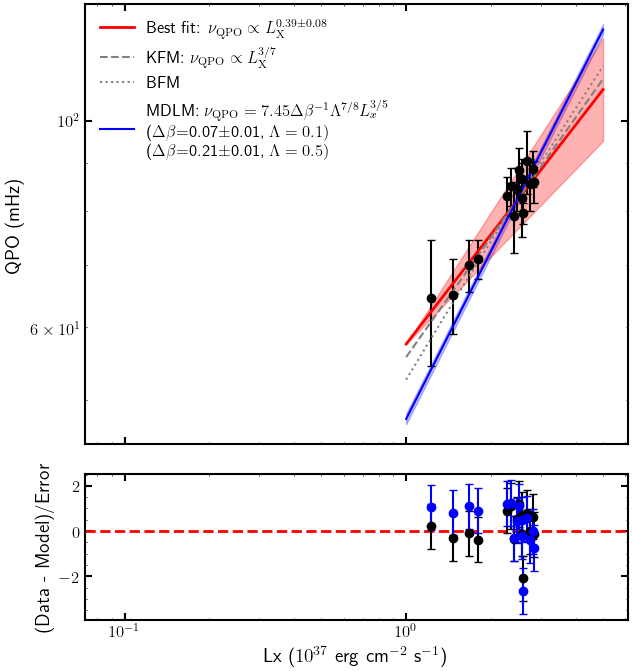

拟合得到的 K 值: 17.3902 ± 1.2411
拟合得到的 Gamma 值: 0.3921 ± 0.0792
拟合得到的 K1 值: 17.9620 ± 0.2355
拟合得到的 Beta 值: 0.0683 ± 0.0009
r2_power 拟合的 R² 值: 0.8529
r2_r 拟合的 R² 值: 0.6966


In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
# 计算 L37 (转换为 10^37 erg/s)
L37 = x1
y2=y1
y2_err=y1_err
x2=x1


# 给定的常量
m = 1.4  # 归一化质量
R6 = 1.0  # 归一化半径 (R6 = R / 10^6 cm)
B12 = 6.7  # 归一化磁场强度 (B12 = B / 10^12 G)
d_kpc = 5  # 距离 (kpc)
Lambda = 0.5  # 假设 Lambda = 0.5
d_cm = d_kpc * 3.086e21  # 转换为 cm


# 定义 t_th 拟合函数 (alpha 作为拟合参数)
def f_power_fit(L37, K, Gamma):
    return 1000 / (K * L37 ** (-Gamma))

def f_power_fit1(L37, K):
    return 1000 / (K * L37 ** (-3/7))

def f_power_fit2(L37, K):
    return 1000 / (K * L37 ** (-3/7))-9.67

def f_power_fit3(L37, K):
    return 1000 / (K * L37 ** (-0.55))

# 定义 t_r 拟合函数 (Beta 作为拟合参数)
def f_r_fit(L37, Beta):
    return 1000 / (12 * Beta * Lambda**(-7/8) * m**(-13/20) * R6**(29/10) * B12**(3/2) * L37**(-3/5))

# def f_r_fit(L37, Beta):
#     return 7.45* Beta**(-1) * Lambda**(7/8) * L37**(3/5)


# 初始参数
Beta_init = 0.01
Gamma_init = 0.6
K_init = 30


# 拟合 f_power_fit
popt_power, pcov_power = curve_fit(f_power_fit, L37, y2, sigma=y2_err, absolute_sigma=True, p0=[K_init, Gamma_init])
K_opt, Gamma_opt = popt_power
perr_power = np.sqrt(np.diag(pcov_power))  # 参数误差

# 拟合 f_power_fit1
popt_power1, pcov_power1 = curve_fit(f_power_fit1, L37, y2, sigma=y2_err, absolute_sigma=True, p0=[K_init])
K1_opt = popt_power1[0]
perr_power1 = np.sqrt(np.diag(pcov_power1))

# 拟合 f_power_fit2
popt_power2, pcov_power2 = curve_fit(f_power_fit2, L37, y2, sigma=y2_err, absolute_sigma=True, p0=[K_init])
K2_opt = popt_power2[0]
perr_power2 = np.sqrt(np.diag(pcov_power2))

# 拟合 f_power_fit3
popt_power3, pcov_power3 = curve_fit(f_power_fit3, L37, y2, sigma=y2_err, absolute_sigma=True, p0=[K_init])
K3_opt = popt_power3[0]
perr_power3 = np.sqrt(np.diag(pcov_power3))

# 拟合 f_r_fit
popt_r, pcov_r = curve_fit(f_r_fit, L37, y2, sigma=y2_err, absolute_sigma=True, p0=[Beta_init])
Beta_opt = popt_r[0]
perr_r = np.sqrt(np.diag(pcov_r))

# 计算拟合曲线
L37_fit = np.linspace(1, 5, 1000)


f_power_fit_values = f_power_fit(L37_fit, K_opt, Gamma_opt)
f_power_fit1_values = f_power_fit1(L37_fit, K1_opt)
f_power_fit2_values = f_power_fit2(L37_fit, K2_opt)
f_power_fit3_values = f_power_fit3(L37_fit, K3_opt)
f_r_fit_values = f_r_fit(L37_fit, Beta_opt)

# 计算残差
residuals_power = (y2 - f_power_fit(L37, K_opt, Gamma_opt)) / y2_err
residuals_power1 = (y2 - f_power_fit1(L37, K1_opt)) / y2_err
residuals_power2 = (y2 - f_power_fit2(L37, K2_opt)) / y2_err
residuals_power3 = (y2 - f_power_fit3(L37, K3_opt)) / y2_err
residuals_r = (y2 - f_r_fit(L37, Beta_opt)) / y2_err

# 计算 R² 值
def r_squared(y_obs, y_fit):
    ss_res = np.sum((y_obs - y_fit) ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_power = r_squared(y2, f_power_fit(L37, K_opt, Gamma_opt))
r2_power1 = r_squared(y2, f_power_fit1(L37, K1_opt))
r2_power2 = r_squared(y2, f_power_fit2(L37, K2_opt))
r2_power3 = r_squared(y2, f_power_fit3(L37, K3_opt))
r2_r = r_squared(y2, f_r_fit(L37, Beta_opt))

# 创建子图
fig, axs = plt.subplots(2, 1, figsize=(7, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
#axs[0].set_xscale('log')
#axs[0].set_yscale('log')
axs[0].set_ylabel(r'QPO (mHz)')
#axs[0].set_title(r'Luminosity vs. QPO')

# axs[1].set_xscale('log')
axs[1].set_xlabel(r'Lx ($10^{37}$ erg cm$^{-2}$ s$^{-1}$)')
axs[1].set_ylabel("(Data - Model)/Error")

# 第一张子图: 拟合曲线

axs[0].errorbar(x2, y2, yerr=y2_err, fmt='o', color='black', capsize=3)
axs[0].plot(L37_fit, f_power_fit_values, label=r"Best fit: $\nu_{\rm QPO}\propto L_{\rm X}^{%0.2f\pm%0.2f}$"%(Gamma_opt,perr_power[1]), color='red',lw=2)
axs[0].plot(L37_fit, f_power_fit1_values, label=r"KFM: $\nu_{\rm QPO}\propto L_{\rm X}^{3/7}$", color='gray',ls='--')
axs[0].plot(L37_fit, f_power_fit2_values, label=r"BFM", color='gray',ls=':')
#axs[0].plot(L37_fit, f_power_fit3_values, label=r"MDPM: $\nu_{\rm QPO}\propto L_{x}^{0.55}}$", color='green')
axs[0].plot(L37_fit, f_r_fit_values, 
            label=r"MDLM: $\nu_{\rm QPO} =  7.45\Delta\beta^{-1}\Lambda^{7/8} L_{x}^{3/5}$"+"\n" +r"($\Delta \beta$=%.2f±0.01, $\Lambda=0.1)$"%Beta_opt+"\n" + r"($\Delta \beta$=0.21±0.01, $\Lambda=0.5)$", 
            color='blue')
# ===== Beta 不确定性阴影（MDLM）=====

Beta_upper = Beta_opt + perr_r[0]
Beta_lower = Beta_opt - perr_r[0]

# 注意：beta 在分母里，upper/lower 会反过来
fit_r_upper = f_r_fit(L37_fit, Beta_lower)  # beta 小 → 频率大
fit_r_lower = f_r_fit(L37_fit, Beta_upper)  # beta 大 → 频率小

axs[0].fill_between(
    L37_fit,
    fit_r_lower,
    fit_r_upper,
    color='blue',
    alpha=0.25
)

# 计算误差上下界对应的拟合曲线
Gamma_upper = Gamma_opt + perr_power[1]
Gamma_lower = Gamma_opt - perr_power[1]

fit_upper = f_power_fit(L37_fit, K_opt, Gamma_upper)
fit_lower = f_power_fit(L37_fit, K_opt, Gamma_lower)

# 添加拟合曲线误差阴影区域
axs[0].fill_between(L37_fit, fit_lower, fit_upper, color='red', alpha=0.3)


axs[0].legend(loc='upper left')
axs[0].set_xscale('log')
axs[0].set_yscale('log')



#axs[0].set_xlim(1.7,11.5)
# 第二张子图: 残差
axs[1].axhline(0, color='red', linestyle='--', linewidth=2)
axs[1].errorbar(x2, residuals_power, yerr=y2_err/y2_err, fmt='o', color='black',capsize=3)
# axs[1].errorbar(x, residuals_power1, yerr=y_err/y_err, fmt='o', color='gray',capsize=3)
# axs[1].errorbar(x, residuals_power2, yerr=y_err/y_err, fmt='o', color='gray',capsize=3)
# axs[1].errorbar(x, residuals_power3, yerr=y_err/y_err, fmt='o', color='green',capsize=3)
axs[1].errorbar(x2, residuals_r, yerr=y2_err/y2_err, fmt='o', color='blue',capsize=3)
#axs[1].errorbar(x[24:], residuals_r[24:], yerr=y_err[24:]/y_err[24:], fmt='s', color='green', capsize=3)
#axs[1].set_ylim(-3.5,3.5)
axs[1].set_xscale('log')
#plt.tight_layout()




from matplotlib.ticker import LogLocator, ScalarFormatter

# axs[0].xaxis.set_major_locator(LogLocator(base=10, subs=[2, 3, 4, 6, 10]))
# axs[0].xaxis.set_major_formatter(ScalarFormatter())

# axs[0].yaxis.set_major_locator(LogLocator(base=10, subs=[30, 40, 60, 80, 100]))
# axs[0].yaxis.set_major_formatter(ScalarFormatter())

# axs[0].set_xlim(1.5,15)
# axs[1].set_xlim(1.5,15)
#plt.tight_layout
plt.subplots_adjust(wspace=0, hspace=0.1)
#plt.savefig('QPO_Lum_modelfit_new.pdf')
plt.show()

# 输出拟合结果
print(f"拟合得到的 K 值: {K_opt:.4f} ± {perr_power[0]:.4f}")
print(f"拟合得到的 Gamma 值: {Gamma_opt:.4f} ± {perr_power[1]:.4f}")
print(f"拟合得到的 K1 值: {K1_opt:.4f} ± {perr_power1[0]:.4f}")
print(f"拟合得到的 Beta 值: {Beta_opt:.4f} ± {perr_r[0]:.4f}")
print(f"r2_power 拟合的 R² 值: {r2_power:.4f}")
print(f"r2_r 拟合的 R² 值: {r2_r:.4f}")




In [93]:
flux0=10**(-8.18397)
luminosity0 = 4 * np.pi * d_cm**2 * flux0
luminosity0

1.9587171059906138e+37

<ErrorbarContainer object of 3 artists>

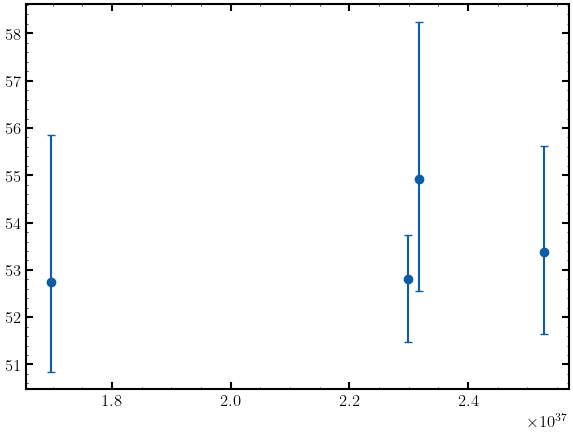

In [94]:
L_x=[2.2982735351750277e+37, 2.5279688380373897e+37, 1.6965306734778619e+37, 2.3166035426411905e+37] #20260128-20260201
E_cyc=[52.8163, 53.3829, 52.7420, 54.9314]
E_cyc_errL=[1.34428, 1.74744, 1.9, 2.38762]
E_cyc_errR=[0.920811, 2.24466, 3.1, 3.31067]
plt.errorbar(L_x, E_cyc, yerr=[E_cyc_errL, E_cyc_errR], fmt='o', capsize=3)